In [53]:
# import all packages
import numpy as np
import pandas as pd
import glob, os
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import math
import statsmodels.formula.api as sm
from statsmodels.stats.anova import anova_lm
import geopandas as gpd
# from plot_functions import plot_50states

### Read roadway lengths

In [54]:
folder_path = r'D:\Work\Box Sync\Quantify Infrastructure\Streets_df\All states'

# Get a list of all CSV files in the folder
csv_files = [file for file in os.listdir(folder_path) if file.endswith('.csv')]

# Initialize an empty DataFrame to store concatenated data
concatenated_df = pd.DataFrame()

# Loop through each CSV file and concatenate them
for file in csv_files:
    # print(file)
    file_path = os.path.join(folder_path, file)
    
    # Read the CSV file into a DataFrame
    df_state = pd.read_csv(file_path, index_col =0)
    # to check how many places are excluded
    # print(df_state.shape[0])
    # count = count + df_state.shape[0]
    df_state['GEOID'] = df_state['GEOID'].astype(str).str.rjust(7, '0')
    
    # Concatenate the DataFrame to the existing data
    concatenated_df = pd.concat([concatenated_df, df_state], ignore_index=True)
print(concatenated_df.shape)

# 13 missing places due to missing geometry
# Total no of places for 50 states in 2020
# 31249+13 = 31262

(31249, 16)


In [55]:
os.environ['USE_PYGEOS'] = '0'
# Import places map
places_US = gpd.read_file(r'D:\Work\Box Sync\Quantify Infrastructure\MapData\all_places\compiled.shp')
print(places_US.shape)

places_50_states = places_US[(places_US['STATEFP'] != '02') & (places_US['STATEFP'] != '60') & (places_US['STATEFP'] != '66') & (places_US['STATEFP'] != '69') & (places_US['STATEFP'] != '72') & (places_US['STATEFP'] != '78')]

print(places_50_states.shape)

KeyboardInterrupt: 

<Axes: >

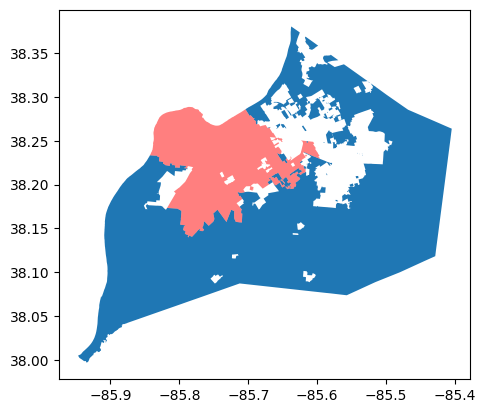

In [ ]:
ax = places_50_states[places_50_states['GEOID'] == '2148006'].plot() # 	Louisville/Jefferson County metro government 
places_50_states[places_50_states['GEOID'] == '2148000'].plot(ax=ax, color='red', alpha = 0.5) # 	Louisville city

In [ ]:
# concatenated_df.dtypes
concatenated_df.head()

,GEOID,NAMELSAD,motorway,trunk,primary,secondary,tertiary,unclassified,residential,cl_motorway,cl_trunk,cl_primary,cl_secondary,cl_tertiary,cl_unclassified,cl_residential
0,0102260,Ardmore town,0,0,[4982.59329295],[4515.60248183],[3414.7747859],[4679.35177942],[37801.08648814],0,0,[2491.29664647],[2276.2207127],[1707.38739295],[2339.67588971],[18935.83231101]
1,0151264,Mooresville town,[136.16154155],0,0,0,[1221.0092178],0,[4847.4987655],[136.16154155],0,0,0,[610.5046089],0,[2454.80585472]
2,0171496,Somerville town,0,0,0,[16702.05036983],0,0,[42007.38767528],0,0,0,[8351.02518492],0,0,[20623.51394204]
3,0176872,Trinity town,0,[3921.7328301],0,0,[24753.43964382],[3779.4748859],[64473.20671685],0,[3921.7328301],0,0,[12376.71982191],[1889.73744295],[31451.06650643]
4,0130880,Goshen town,0,0,0,0,[12662.95531831],[2292.40449468],[16229.56523005],0,0,0,0,[6331.47765916],[1146.20224734],[8114.78261503]


In [ ]:
df = concatenated_df.copy()

In [ ]:
# Convert link lengths from str of list elements to float 
def str_to_float(df, column_name):
    return df[column_name].str.replace("[","").str.replace("]","").astype(float)

column_list = ['motorway', 'trunk', 'primary', 'secondary', 'tertiary', 'unclassified', 'residential', 
               'cl_motorway', 'cl_trunk', 'cl_primary', 'cl_secondary', 'cl_tertiary', 'cl_unclassified', 'cl_residential']


for column in column_list:
    df[column] = str_to_float(df, column)

In [ ]:
# Calculate total roadway length and total centerline roadway length
roadway_columns = ['motorway', 'trunk', 'primary', 'secondary', 'tertiary', 'unclassified', 'residential']
cl_roadway_columns = ['cl_motorway', 'cl_trunk', 'cl_primary', 'cl_secondary', 'cl_tertiary', 'cl_unclassified', 'cl_residential']

df['total_length'] = df[roadway_columns].sum(axis=1)
df['cl_total_length'] = df[cl_roadway_columns].sum(axis=1)

In [ ]:
df['road_area_m2'] = df['motorway'] * 13.6 + df['trunk'] * 9.6 + df['primary'] * 6.0 + df['secondary'] * 5.3 + df['tertiary'] * 4.9 + df['unclassified'] * 4.5 + df['residential'] * 4.5

In [ ]:
df['road_area_m2'].sum()/1000000

21989.674451979547

In [ ]:
# NaNs values in roadway length dataframe
df.isna().sum().sum()

0

### Import population and attributes data from depopulation study

In [ ]:
df_population = pd.read_csv(r'D:\Work\Box Sync\Quantify Infrastructure\DavidFrantzData\forecasted_trend.csv', index_col  = 0)
df_population['GEOID'] = df_population['GEOID'].astype(str).str.rjust(7,'0')

df_attributes = pd.read_csv(r'D:\Work\Box Sync\Quantify Infrastructure\DavidFrantzData\df_attributes.csv', index_col  = 0)
df_attributes['GEOID'] = df_attributes['GEOID'].astype(str).str.rjust(7,'0')

df_pop_attr = df_population.merge(df_attributes[['GEOID', 'REGION', 'city type', 'weighted_HU_density_sqmi','median_income','ALAND']], on = 'GEOID')
print(df_population.shape, df_attributes.shape, df_pop_attr.shape)


(31617, 58) (31908, 33) (31616, 62)


In [ ]:
# Total population for SSP 2 for each 10 yr interval
print('Total population in millions for 51 states: ===')
df_population[['CensusPop_20','ssp22020', 'ssp22030', 'ssp22040', 'ssp22050', 'ssp22060','ssp22070', 'ssp22080', 'ssp22090', 'ssp22100']].sum() / 1000000

Total population in millions for 51 states: ===


CensusPop_20    249.755152
ssp22020        250.994929
ssp22030        271.282551
ssp22040        289.394587
ssp22050        305.168766
ssp22060        320.539073
ssp22070        334.443119
ssp22080        344.689135
ssp22090        350.775132
ssp22100        353.489903
dtype: float64

### Merge roads with population

In [ ]:
roads_with_pop_all = df.merge(df_pop_attr[['GEOID', 'State', 'REGION', 'ALAND', 'label', 'future trend from SSP 2', 'CensusPop_20', 'city type','weighted_HU_density_sqmi','median_income',
                                       'ssp22020', 'ssp22030', 'ssp22040', 'ssp22050','ssp22060', 'ssp22070', 'ssp22080',
                                       'ssp22090','ssp22100', 'ssp12020', 'ssp12030', 'ssp12040', 'ssp12050', 'ssp12060','ssp12070', 
                                                   'ssp12080', 'ssp12090', 'ssp12100', 'ssp42020', 'ssp42030', 'ssp42040', 'ssp42050', 'ssp42060',
                                                   'ssp42070', 'ssp42080', 'ssp42090', 'ssp42100']], on = 'GEOID', how='left')
print(roads_with_pop_all.shape)

print(roads_with_pop_all[roads_with_pop_all['GEOID'].str.startswith('214800')][['GEOID', 'NAMELSAD','CensusPop_20', 'ssp22020', 'ssp22030', 'ssp22040', 'ssp22050']])
# 2010 Census
# Louisville/Jefferson County metro government (balance), Kentucky	597337
# 2020 Census
# Louisville city, Kentucky	246161
# Louisville/Jefferson County metro government (balance), Kentucky	386884

# 246161+386884 = 633045

print('Total population in millions for 50 states: ===')
print(roads_with_pop_all[['CensusPop_20', 'ssp22020', 'ssp22030', 'ssp22040', 'ssp22050', 'ssp22060','ssp22070', 'ssp22080', 'ssp22090', 'ssp22100']].sum() / 1000000)

roads_with_pop_all['percentchangeinpop'] = np.abs((roads_with_pop_all['ssp42020'] - roads_with_pop_all['CensusPop_20'])/roads_with_pop_all['CensusPop_20'])
# cities that have their 2020 census population with 1% variation of the projected ssp22020 population are included in the analysis
roads_with_pop = roads_with_pop_all[(roads_with_pop_all['percentchangeinpop'] <=.01)]
print(roads_with_pop.shape)
# roads_with_pop_all[roads_with_pop_all['percentchangeinpop'] > 0.01][['GEOID','NAMELSAD', 'CensusPop_20', 'ssp22020',]].sort_values(by='ssp22020')

(31249, 54)
         GEOID                                           NAMELSAD  \
10245  2148006  Louisville/Jefferson County metro government (...   
10405  2148000                                    Louisville city   

       CensusPop_20     ssp22020     ssp22030     ssp22040     ssp22050  
10245      386884.0  389068.4372  424417.2341  456660.9352  485264.1312  
10405           NaN          NaN          NaN          NaN          NaN  
Total population in millions for 50 states: ===
CensusPop_20    248.779899
ssp22020        250.287579
ssp22030        270.511862
ssp22040        288.564911
ssp22050        304.282673
ssp22060        319.590817
ssp22070        333.443879
ssp22080        343.642158
ssp22090        349.691666
ssp22100        352.378215
dtype: float64
(30573, 55)


### Read redefined urban rural classes

In [ ]:
df_urban_rural_conn = pd.read_csv(r'D:\Work\Box Sync\Quantify Infrastructure\output_csvs\output_city_type.csv')
df_urban_rural_conn = df_urban_rural_conn[['GEOID','citytype_at_2030',  'citytype_at_2040', 'citytype_at_2050', 'citytype_at_2060',
                                           'citytype_at_2070',  'citytype_at_2080', 'citytype_at_2090', 'citytype_at_2100']]
                                           
df_urban_rural_conn['GEOID'] = df_urban_rural_conn['GEOID'].astype(str).str.rjust(7,'0')

roads_with_pop = roads_with_pop.merge(df_urban_rural_conn, on = 'GEOID')

In [ ]:
roads_with_pop.shape

(30537, 63)

### Model comparision Pruned Nonpruned F_test

In [ ]:
roads_with_pop['per_cap_mass_at_2020'] =  roads_with_pop['cl_total_length'] / roads_with_pop['CensusPop_20']

stocks_with_pop = roads_with_pop[roads_with_pop['CensusPop_20'] != 0]
stocks_with_pop = stocks_with_pop[stocks_with_pop['city type'] == 'suburban']
print(stocks_with_pop.shape)

infra_col ='cl_total_length'
pop_col = 'CensusPop_20'
df = stocks_with_pop.copy()

### ============== PRUNING ============== ###
# Set the threshold to the 90th percentile
threshold_u = df[infra_col].quantile(0.9)
threshold_l = df[infra_col].quantile(0.1)
# Filter the DataFrame to include only points in the top 10%
df_pruned = df[df[infra_col] < threshold_u]
df_pruned = df_pruned[df_pruned[infra_col] > threshold_l]
print(df_pruned.shape)

y = np.log(df[infra_col].astype(float))
x = np.log(df[pop_col].astype(float))

y_pruned = np.log(df_pruned[infra_col].astype(float))
x_pruned = np.log(df_pruned[pop_col].astype(float)) 

m01 = sm.ols("y ~ x", data={"y": y, "x": x}).fit()
print(m01.params)
print("R-squared value" , m01.rsquared)
m02 = sm.ols("y_pruned ~ x_pruned", data={"y_pruned": y_pruned, "x_pruned": x_pruned}).fit()
anova_results= anova_lm(m01, m02)
print(m02.params)
print("R-squared value" , m02.rsquared)
print(anova_results)
print('\n')

if anova_results['Pr(>F)'][1] < 0.005:
    print(f"Since {anova_results['Pr(>F)'][1]} < 0.005, difference is significant")
    print("Built pruned model")


(6885, 64)
(5507, 64)
Intercept    3.924751
x            0.828891
dtype: float64
R-squared value 0.8511531245954935
Intercept    5.147044
x_pruned     0.691241
dtype: float64
R-squared value 0.7203504996785941
   df_resid          ssr  df_diff     ss_diff         F         Pr(>F)
0    6883.0  1794.477208      0.0         NaN       NaN            NaN
1    5505.0  1132.872134   1378.0  661.605073  2.333061  1.380779e-102


Since 1.3807790646000282e-102 < 0.005, difference is significant
Built pruned model


total_area: 374.0667284072186
total_area: 658.6219515875762


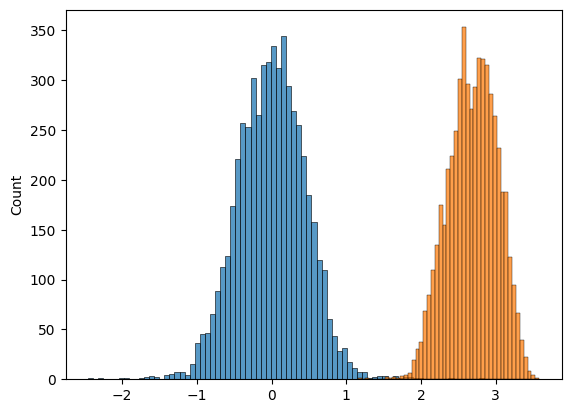

In [ ]:
ax = sns.histplot(m02.resid)
values_sns = [h.get_height() for h in ax.patches]
bins_sns = [h.get_width() for h in ax.patches]

# total_area = sum([height * width for height, width in zip(values_sns, bins_sns)])
total_area = np.sum(np.array(bins_sns) * np.array(values_sns)) # shorter, faster using numpy
print("total_area:", total_area)  # 1.0

ax = sns.histplot((m02.resid + m02.params.Intercept) - np.log(df_pruned['per_cap_mass_at_2020']))
# Source: https://stackoverflow.com/questions/62569955/calculate-the-area-under-the-histogram-with-seaborn
values_sns = [h.get_height() for h in ax.patches]
bins_sns = [h.get_width() for h in ax.patches]

# total_area = sum([height * width for height, width in zip(values_sns, bins_sns)])
total_area = np.sum(np.array(bins_sns) * np.array(values_sns)) # shorter, faster using numpy
print("total_area:", total_area)  # 1.0

### Find next stock

In [ ]:
pd.set_option('mode.chained_assignment', None) # To stop SettingWithCopy warning
list_of_city_types = ['urban', 'suburban', 'periurban', 'rural']

In [ ]:
print('Total NaNs in population and roadway length:===')
print(roads_with_pop[['CensusPop_20', 'ssp22040', 'total_length']].isna().sum())
print("Places with no roadway:===", roads_with_pop[roads_with_pop['cl_total_length'] == 0].shape[0])
print("Places with zero population in census 2020:===", roads_with_pop[roads_with_pop['CensusPop_20'] == 0].shape[0])
print("Places with no available population forecast:===", roads_with_pop[roads_with_pop['ssp22040'].isnull()].shape[0])
print(roads_with_pop.shape)

Total NaNs in population and roadway length:===
CensusPop_20    0
ssp22040        0
total_length    0
dtype: int64
Places with no roadway:=== 0
Places with zero population in census 2020:=== 0
Places with no available population forecast:=== 0
(30537, 64)


In [ ]:
roads_clean = roads_with_pop.dropna(subset=['CensusPop_20', 'ssp22040', 'total_length', 'cl_total_length']).reset_index(drop=True)

current_roadway_column = 'cl_total_length' # 'road_area_m2' # 

roads_clean['per_cap_mass_at_2020'] = roads_clean[current_roadway_column] / roads_clean['CensusPop_20'].round(0)
print("Shape of the clean dataset with nonzero values:==")
print(roads_clean.shape)
print(roads_clean[(roads_clean['per_cap_mass_at_2020'] > 10000) | (roads_clean['total_length'] < 500)][['GEOID', 'NAMELSAD','CensusPop_20','total_length', 'cl_total_length','per_cap_mass_at_2020']])
# roads_clean = roads_clean.merge(df_urban_rural_conn, on ='GEOID')
roads_clean = roads_clean[(roads_clean['per_cap_mass_at_2020'] <= 10000) & (roads_clean['total_length'] >= 500)]
print("Shape of the clean dataset with newly defined urban rural continuum at each time interval values:==")
print(roads_clean.shape)

Shape of the clean dataset with nonzero values:==
(30537, 64)
         GEOID              NAMELSAD  CensusPop_20   total_length  \
686    0401170        Alamo Lake CDP           4.0  120493.451000   
4056   1205150   Belleair Shore town          73.0     172.774243   
15219  3063266  Riverview Colony CDP         100.0      15.341483   
17644  3664881      Saltaire village         113.0       7.194151   

       cl_total_length  per_cap_mass_at_2020  
686       60246.725500          15061.681375  
4056         98.251819              1.345915  
15219         7.670742              0.076707  
17644         3.597076              0.031833  
Shape of the clean dataset with newly defined urban rural continuum at each time interval values:==
(30533, 64)


In [ ]:
# roads_clean[['per_cap_mass_at_2020','road_area_m2', ]]

In [ ]:
''''
Notes:
1. Roadway lengths are measured in meters 
2. Centrerline total has been used for scale fitting and projecting. Lengths were checked with google maps, DOT values for some cities and 
centerline values seemed more reasonable then total length
roads_clean[roads_clean['NAMELSAD'].str.startswith('New York')][['GEOID', 'NAMELSAD', 'total_length', 'cl_total_length',]]
3. Cities with less than 1 km total roadway and over 10 km/person roadways were excluded from modeling
that inculdes three cities, Saltaire village (NY), Riverview Colony CDP (Montana), and Alamo Lake CDP (AZ)

'''


"'\nNotes:\n1. Roadway lengths are measured in meters \n2. Centrerline total has been used for scale fitting and projecting. Lengths were checked with google maps, DOT values for some cities and \ncenterline values seemed more reasonable then total length\nroads_clean[roads_clean['NAMELSAD'].str.startswith('New York')][['GEOID', 'NAMELSAD', 'total_length', 'cl_total_length',]]\n3. Cities with less than 1 km total roadway and over 10 km/person roadways were excluded from modeling\nthat inculdes three cities, Saltaire village (NY), Riverview Colony CDP (Montana), and Alamo Lake CDP (AZ)\n\n"

In [ ]:
# roads_clean[['GEOID', 'NAMELSAD','CensusPop_20','weighted_HU_density_sqmi','total_length', 'cl_total_length', 'per_cap_mass_at_2020']].sort_values(by=['per_cap_mass_at_2020']).tail(20)

### Run loops 

### for 2030

(30533, 26)
Initial dataframe:====
(30533, 26)
Shape of the dataframe for urban:====
(312, 27)
Prune upper and lower 10 percent data before fitting to the scaling law
***DEFINITELY NEED TO VALIDATE THIS PRUNING***
Shape of dataframe used in scaling fit:===
(280, 27)


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.885
Model:                            OLS   Adj. R-squared:                  0.884
Method:                 Least Squares   F-statistic:                     2133.
Date:                Thu, 23 May 2024   Prob (F-statistic):          1.98e-132
Time:                        16:53:14   Log-Likelihood:                -200.91
No. Observations:                 280   AIC:                             405.8
Df Residuals:                     278   BIC:                             413.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.7989      0.226      7.957      0.0

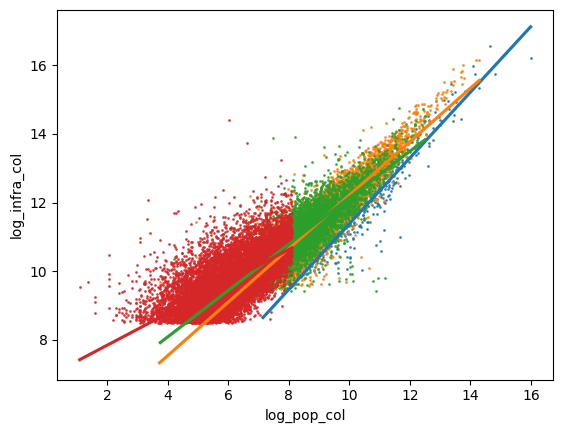

In [ ]:
import sys
# caution: path[0] is reserved for script path (or '' in REPL)
sys.path.insert(1, r'D:\Work\Box Sync\Quantify Infrastructure\Scripts\scenarios')
from functions.functions_scaling import find_scale_parameters, find_next_stock, process_stock_at_t


current_stock_col = 'cl_total_length'
current_pop_col = 'CensusPop_20'
next_pop_col = 'ssp22030'
t = 2030

df_for_analysis = roads_clean[['GEOID', 'State', 'NAMELSAD','city type','median_income', 'road_area_m2', 'CensusPop_20', 'ssp22020', 'ssp22030', 
                                'ssp22040', 'ssp22050', 'ssp22060', 'ssp22070', 'ssp22080', 'ssp22090', 'ssp22100',
                                'citytype_at_2030', 'citytype_at_2040','citytype_at_2050', 'citytype_at_2060', 'citytype_at_2070',  'citytype_at_2080', 'citytype_at_2090', 'citytype_at_2100',
                                'cl_total_length', 'total_length']]


df_for_2030 = process_stock_at_t(df_for_analysis, current_stock_col, current_pop_col, next_pop_col, t)

df_for_analysis = df_for_analysis.merge(df_for_2030, on ='GEOID')
roads_clean = roads_clean.merge(df_for_2030, on ='GEOID')
print(roads_clean.shape)

df_for_analysis.rename({'surface_Res_at_2030' : 'cl_length_at_2030'}, axis=1, inplace=True)

### 2040 - 2100

(30533, 29)
Initial dataframe:====
(30533, 29)
Shape of the dataframe for urban:====
(325, 29)
Prune upper and lower 10 percent data before fitting to the scaling law
***DEFINITELY NEED TO VALIDATE THIS PRUNING***
Shape of dataframe used in scaling fit:===
(292, 29)
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.883
Model:                            OLS   Adj. R-squared:                  0.883
Method:                 Least Squares   F-statistic:                     2193.
Date:                Thu, 23 May 2024   Prob (F-statistic):          2.91e-137
Time:                        16:54:23   Log-Likelihood:                -206.07
No. Observations:                 292   AIC:                             416.1
Df Residuals:                     290   BIC:                             423.5
Df Model:                           1                                         
Covariance Type:      

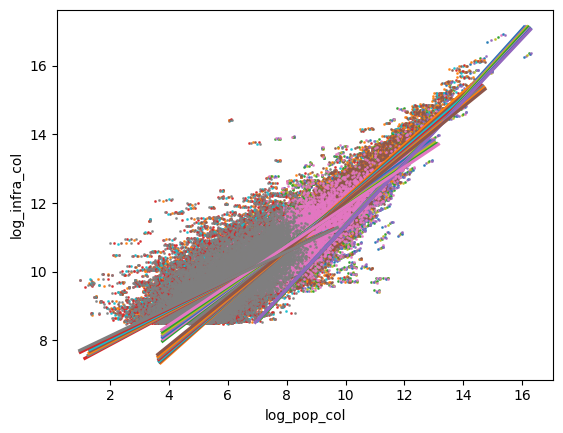

In [ ]:
current_stock_col ='cl_length_at_2030'
current_pop_col = 'ssp22030'
next_pop_col = 'ssp22040'
t = 2040

df_for_2040 = process_stock_at_t(df_for_analysis, current_stock_col, current_pop_col, next_pop_col, t)

df_for_analysis = df_for_analysis.merge(df_for_2040, on ='GEOID')
roads_clean = roads_clean.merge(df_for_2040, on ='GEOID')
print(roads_clean.shape)

df_for_analysis.rename({'surface_Res_at_2040' : 'cl_length_at_2040'}, axis=1, inplace=True)

current_stock_col ='cl_length_at_2040'
current_pop_col = 'ssp22040'
next_pop_col = 'ssp22050'
t = 2050

df_for_2050 = process_stock_at_t(df_for_analysis, current_stock_col, current_pop_col, next_pop_col, t)

df_for_analysis = df_for_analysis.merge(df_for_2050, on ='GEOID')
roads_clean = roads_clean.merge(df_for_2050, on ='GEOID')
print(roads_clean.shape)
df_for_analysis.rename({'surface_Res_at_2050' : 'cl_length_at_2050'}, axis=1, inplace=True)


current_stock_col ='cl_length_at_2050'
current_pop_col = 'ssp22050'
next_pop_col = 'ssp22060'
t = 2060

df_for_2060 = process_stock_at_t(df_for_analysis, current_stock_col, current_pop_col, next_pop_col, t)

df_for_analysis = df_for_analysis.merge(df_for_2060, on ='GEOID')
roads_clean = roads_clean.merge(df_for_2060, on ='GEOID')
print(roads_clean.shape)
df_for_analysis.rename({'surface_Res_at_2060' : 'cl_length_at_2060'}, axis=1, inplace=True)


current_stock_col ='cl_length_at_2060'
current_pop_col = 'ssp22060'
next_pop_col = 'ssp22070'
t = 2070

df_for_2070 = process_stock_at_t(df_for_analysis, current_stock_col, current_pop_col, next_pop_col, t)

df_for_analysis = df_for_analysis.merge(df_for_2070, on ='GEOID')
roads_clean = roads_clean.merge(df_for_2070, on ='GEOID')
print(roads_clean.shape)
df_for_analysis.rename({'surface_Res_at_2070' : 'cl_length_at_2070'}, axis=1, inplace=True)


current_stock_col ='cl_length_at_2070'
current_pop_col = 'ssp22070'
next_pop_col = 'ssp22080'
t = 2080

df_for_2080 = process_stock_at_t(df_for_analysis, current_stock_col, current_pop_col, next_pop_col, t)

df_for_analysis = df_for_analysis.merge(df_for_2080, on ='GEOID')
roads_clean = roads_clean.merge(df_for_2080, on ='GEOID')
print(roads_clean.shape)
df_for_analysis.rename({'surface_Res_at_2080' : 'cl_length_at_2080'}, axis=1, inplace=True)

current_stock_col ='cl_length_at_2080'
current_pop_col = 'ssp22080'
next_pop_col = 'ssp22090'
t = 2090

df_for_2090 = process_stock_at_t(df_for_analysis, current_stock_col, current_pop_col, next_pop_col, t)

df_for_analysis = df_for_analysis.merge(df_for_2090, on ='GEOID')
roads_clean = roads_clean.merge(df_for_2090, on ='GEOID')
print(roads_clean.shape)
df_for_analysis.rename({'surface_Res_at_2090' : 'cl_length_at_2090'}, axis=1, inplace=True)


current_stock_col ='cl_length_at_2090'
current_pop_col = 'ssp22090'
next_pop_col = 'ssp22100'
t = 2100

df_for_2100 = process_stock_at_t(df_for_analysis, current_stock_col, current_pop_col, next_pop_col, t)

df_for_analysis = df_for_analysis.merge(df_for_2100, on ='GEOID')
roads_clean = roads_clean.merge(df_for_2100, on ='GEOID')
print(roads_clean.shape)
df_for_analysis.rename({'surface_Res_at_2100' : 'cl_length_at_2100'}, axis=1, inplace=True)


In [ ]:
roads_clean[['State', 'NAMELSAD', 'per_cap_mass_at_2020', 'per_cap_mass_at_2030', 'per_cap_mass_at_2040', 'per_cap_mass_at_2050','per_cap_mass_at_2060','per_cap_mass_at_2100']].sort_values(by= 'per_cap_mass_at_2020')

,State,NAMELSAD,per_cap_mass_at_2020,per_cap_mass_at_2030,per_cap_mass_at_2040,per_cap_mass_at_2050,per_cap_mass_at_2060,per_cap_mass_at_2100
3068,6.0,Stevenson Ranch CDP,0.225636,0.210875,0.202354,0.198451,0.197252,0.216544
2522,6.0,Hacienda Heights CDP,0.230077,0.212366,0.200462,0.192389,0.186217,0.181568
2746,6.0,Marina del Rey CDP,0.235208,0.229457,0.225412,0.223313,0.222187,0.234719
2653,6.0,Lake Los Angeles CDP,0.241230,0.225906,0.217162,0.213355,0.212366,0.234308
1911,6.0,Baldwin Park city,0.250262,0.230998,0.218058,0.209279,0.202578,0.197561
...,...,...,...,...,...,...,...,...
27561,49.0,Halls Crossing CDP,3878.888274,3878.888274,3878.888274,3923.344422,3923.344422,3961.335372
19501,38.0,Calio city,4310.472237,4335.964235,3870.897643,3882.621172,3895.948721,3560.983643
9256,20.0,Greeley County unified government (balance),4416.076010,4363.899685,4312.790353,4253.024283,4129.102440,3852.168593
14340,29.0,River Bend village,4801.610049,4861.388360,3750.705017,3777.835191,3802.636484,3900.180979


### PLOTS

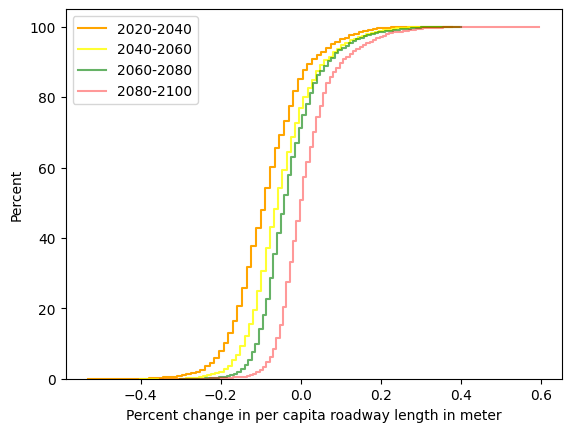

In [ ]:
# roads_clean[roads_clean['per_cap_mass_at_2100'] < roads_clean['per_cap_mass_at_2020']]['per_cap_mass_at_2020'].describe()
data = roads_clean[roads_clean['city type'] == 'suburban']

stat_method = 'percent'
cumulative_method = True

sns.histplot(np.sort((data['per_cap_mass_at_2040'] - data['per_cap_mass_at_2020'])/data['per_cap_mass_at_2020']), alpha = 1.0, color= 'orange', element='step', fill=False, stat= stat_method, cumulative= cumulative_method)
sns.histplot(np.sort((data['per_cap_mass_at_2060'] - data['per_cap_mass_at_2040'])/data['per_cap_mass_at_2040']), alpha = 0.8, color= 'yellow', element='step', fill=False, stat= stat_method, cumulative= cumulative_method)
sns.histplot(np.sort((data['per_cap_mass_at_2080'] - data['per_cap_mass_at_2060'])/data['per_cap_mass_at_2060']), alpha = 0.6, color ='green', element='step', fill=False, stat= stat_method, cumulative= cumulative_method)
sns.histplot(np.sort((data['per_cap_mass_at_2100'] - data['per_cap_mass_at_2080'])/data['per_cap_mass_at_2080']), alpha = 0.4, color ='red', element='step', fill=False, stat= stat_method, cumulative= cumulative_method)
plt.xlabel('Percent change in per capita roadway length in meter')
plt.legend(labels=['2020-2040', '2040-2060', '2060-2080', '2080-2100'])

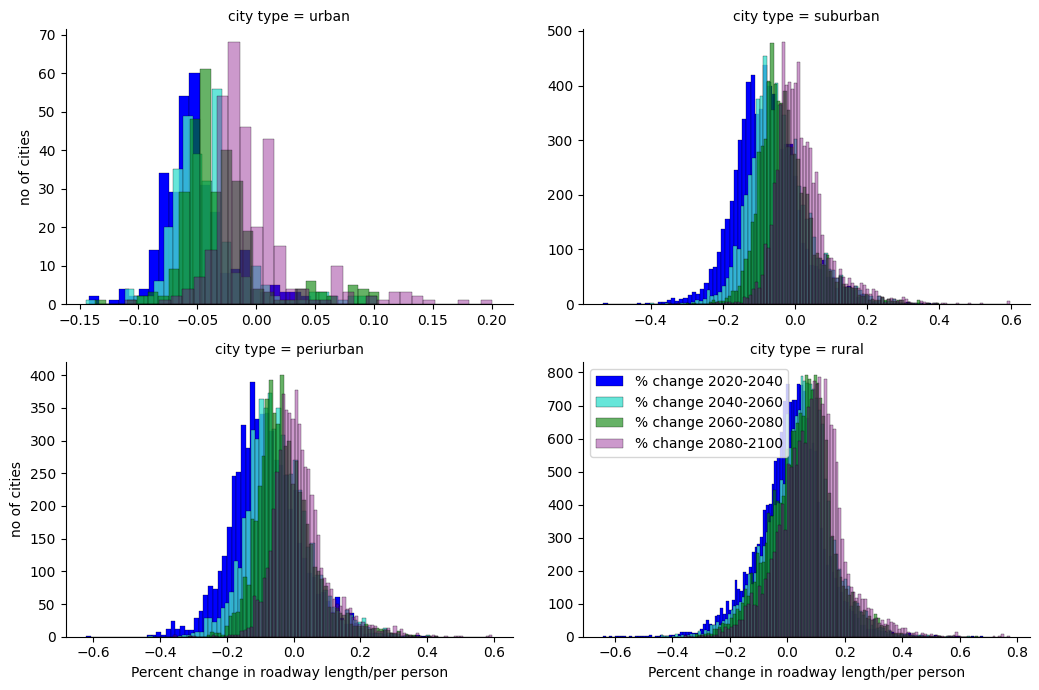

In [ ]:
data = roads_clean

data['percent change from 2020-2040'] = (data['per_cap_mass_at_2040'] - data['per_cap_mass_at_2020'])/data['per_cap_mass_at_2020']
data['percent change from 2040-2060'] = (data['per_cap_mass_at_2060'] - data['per_cap_mass_at_2040'])/data['per_cap_mass_at_2040']
data['percent change from 2060-2080'] = (data['per_cap_mass_at_2080'] - data['per_cap_mass_at_2060'])/data['per_cap_mass_at_2060']
data['percent change from 2080-2100'] = (data['per_cap_mass_at_2100'] - data['per_cap_mass_at_2080'])/data['per_cap_mass_at_2080']

citytype_name = ['urban', 'suburban', 'periurban', 'rural']

# fig, axs = plt.subplots(nrows =2, ncols =2,  figsize=(7, 7))
g = sns.FacetGrid(data, col='city type', col_wrap=2, col_order = ['urban', 'suburban', 'periurban', 'rural'], 
                  sharex=False, sharey=False, margin_titles=False, height=3.5, aspect=1.5)
g.map(sns.histplot,'percent change from 2020-2040', alpha = 1.0, color= 'blue', linewidth=0.2)
g.map(sns.histplot,'percent change from 2040-2060', alpha = 0.8, color= 'Turquoise', linewidth=0.2)
g.map(sns.histplot,'percent change from 2060-2080', alpha = 0.6, color= 'green', linewidth=0.2)
g.map(sns.histplot,'percent change from 2080-2100', alpha = 0.4, color= 'purple', linewidth=0.2)
g.set_axis_labels("Percent change in roadway length/per person", "no of cities")
plt.legend(labels=['% change 2020-2040', '% change 2040-2060', '% change 2060-2080', '% change 2080-2100'])

c:\Users\uttar\miniforge3\envs\analyzeInfra\Lib\site-packages\pandas\core\arraylike.py:396: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\uttar\miniforge3\envs\analyzeInfra\Lib\site-packages\pandas\core\arraylike.py:396: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\uttar\miniforge3\envs\analyzeInfra\Lib\site-packages\pandas\core\arraylike.py:396: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\uttar\miniforge3\envs\analyzeInfra\Lib\site-packages\pandas\core\arraylike.py:396: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\uttar\miniforge3\envs\analyzeInfra\Lib\site-packages\pandas\core\arraylike.py:396: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\uttar\mi

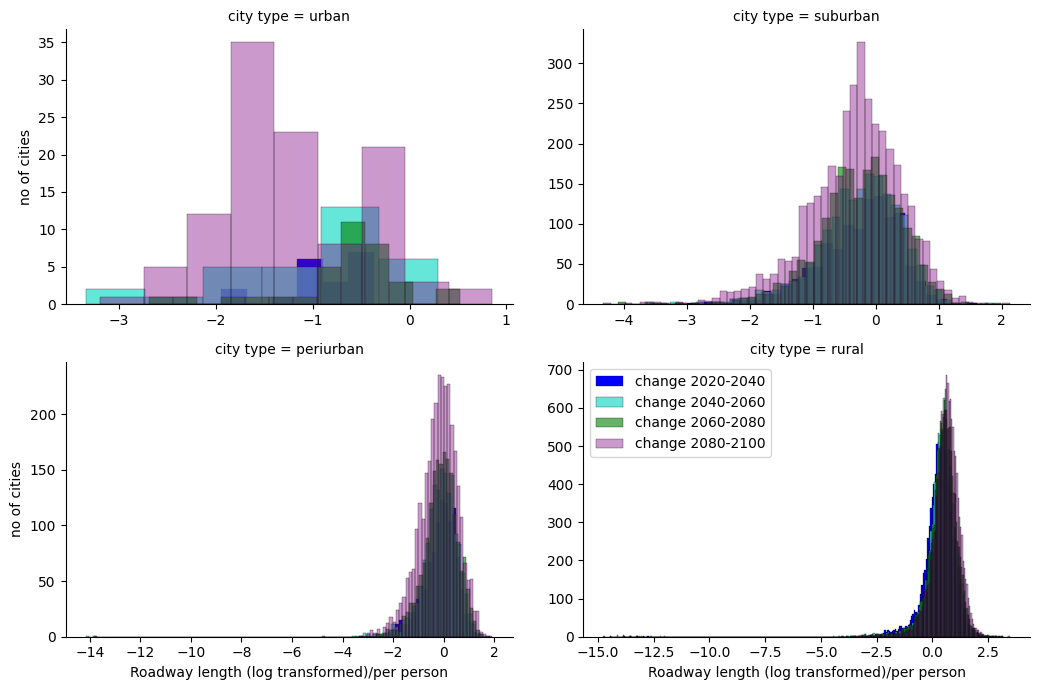

In [ ]:
data = roads_clean

data['m-change from 2020-2040'] = np.log10(data['per_cap_mass_at_2040'] - data['per_cap_mass_at_2020'])
data['m-change from 2040-2060'] = np.log10(data['per_cap_mass_at_2060'] - data['per_cap_mass_at_2040'])
data['m-change from 2060-2080'] = np.log10(data['per_cap_mass_at_2080'] - data['per_cap_mass_at_2060'])
data['m-change from 2080-2100'] = np.log10(data['per_cap_mass_at_2100'] - data['per_cap_mass_at_2080'])

citytype_name = ['urban', 'suburban', 'periurban', 'rural']

# fig, axs = plt.subplots(nrows =2, ncols =2,  figsize=(7, 7))
g = sns.FacetGrid(data, col='city type', col_wrap=2, col_order = ['urban', 'suburban', 'periurban', 'rural'], 
                  sharex=False, sharey=False, margin_titles=False, height=3.5, aspect=1.5)
g.map(sns.histplot,'m-change from 2020-2040', alpha = 1.0, color= 'blue', linewidth=0.2)
g.map(sns.histplot,'m-change from 2040-2060', alpha = 0.8, color= 'Turquoise', linewidth=0.2)
g.map(sns.histplot,'m-change from 2060-2080', alpha = 0.6, color= 'green', linewidth=0.2)
g.map(sns.histplot,'m-change from 2080-2100', alpha = 0.4, color= 'purple', linewidth=0.2)
g.set_axis_labels("Roadway length (log transformed)/per person", "no of cities")
plt.legend(labels=['change 2020-2040', 'change 2040-2060', 'change 2060-2080', 'change 2080-2100'])

In [ ]:
# # import matplotlib
# # matplotlib.rcParams.update(matplotlib.rcParamsDefault)

# citytype_name = ['urban', 'suburban', 'periurban', 'rural']

# # fig, axs = plt.subplots(nrows =2, ncols =2,  figsize=(7, 7))
# data = roads_clean
# data['percent change from 2020-2040'] = (data['per_cap_mass_at_2040'] - data['per_cap_mass_at_2020'])/data['per_cap_mass_at_2020']
# data['percent change from 2040-2060'] = (data['per_cap_mass_at_2060'] - data['per_cap_mass_at_2040'])/data['per_cap_mass_at_2040']
# data['percent change from 2060-2080'] = (data['per_cap_mass_at_2080'] - data['per_cap_mass_at_2060'])/data['per_cap_mass_at_2060']
# data['percent change from 2080-2100'] = (data['per_cap_mass_at_2100'] - data['per_cap_mass_at_2080'])/data['per_cap_mass_at_2080']


# g = sns.FacetGrid(data, col='city type', col_wrap=2, col_order = ['urban', 'suburban', 'periurban', 'rural'], 
#                   sharex=False, sharey=False, margin_titles=False, height=3.5, aspect=1.5)

# g.map(sns.histplot,'percent change from 2020-2040', alpha = 1.0, color= 'Tan', linewidth=0.2, kde=True, fill = False)
# g.map(sns.histplot,'percent change from 2040-2060', alpha = 0.8, color= 'Turquoise', linewidth=0.2, kde=True, fill = False)
# g.map(sns.histplot,'percent change from 2060-2080', alpha = 0.6, color= 'green', linewidth=0.2, kde=True, fill = False)
# g.map(sns.histplot,'percent change from 2080-2100', alpha = 0.4, color= 'purple', linewidth=0.2, kde=True, fill = False)
# g.set_axis_labels("Percent change in roadway length/per person", "no of cities")
# plt.legend(labels=['% change 2020-2040', '% change 2040-2060', '% change 2060-2080', '% change 2080-2100'])

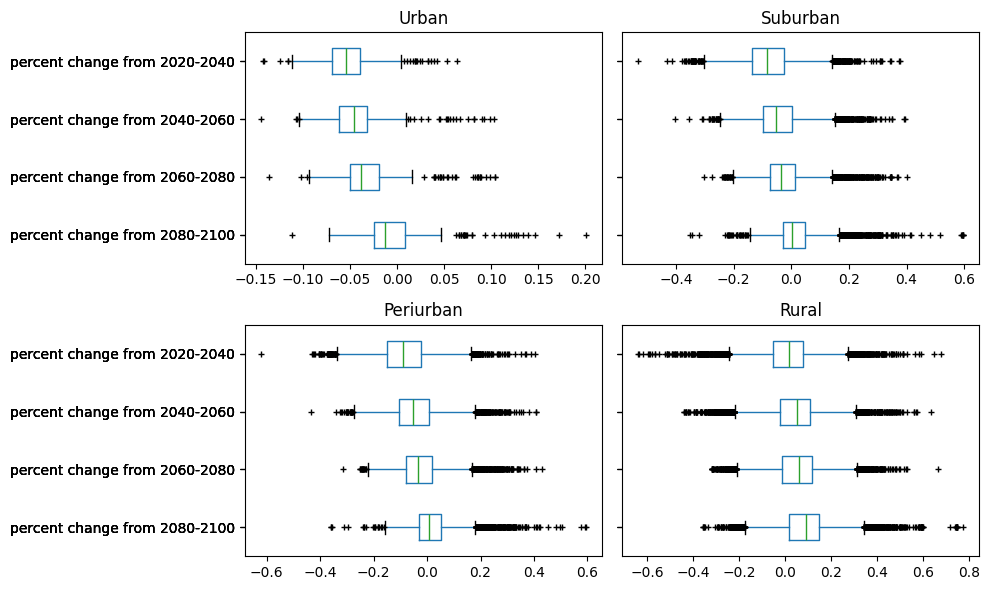

In [ ]:
columns_boxplot = ['percent change from 2080-2100', 'percent change from 2060-2080','percent change from 2040-2060','percent change from 2020-2040']

# Create a figure with subplots
fig, axs = plt.subplots(2, 2, figsize=(10, 6), sharey=True)

# Boxplot for Value1 and Value2 in the first subplot
roads_clean[roads_clean['city type'] == 'urban'][columns_boxplot].boxplot(ax=axs[0, 0], vert=False, sym='+',
                                                                          flierprops={'markersize': 4, 'markerfacecolor': 'fuchsia'}) 
axs[0, 0].set_title('Urban')
# # Boxplot for Value1 and Value3 in the second subplot
roads_clean[roads_clean['city type'] == 'suburban'][columns_boxplot].boxplot(ax=axs[0, 1], vert=False, sym='+',
                                                                          flierprops={'markersize': 4, 'markerfacecolor': 'fuchsia'}) 
axs[0, 1].set_title('Suburban')
# # Boxplot for Value2 and Value3 in the third subplot
roads_clean[roads_clean['city type'] == 'periurban'][columns_boxplot].boxplot(ax=axs[1, 0], vert=False, sym='+',
                                                                          flierprops={'markersize': 4, 'markerfacecolor': 'fuchsia'}) 
axs[1, 0].set_title('Periurban')
# # Boxplot for all three values in the fourth subplot
roads_clean[roads_clean['city type'] == 'rural'][columns_boxplot].boxplot(ax=axs[1, 1], vert=False, sym='+',
                                                                          flierprops={'markersize': 4, 'markerfacecolor': 'fuchsia'}) 
axs[1, 1].set_title('Rural')
# Adjust layout
plt.tight_layout()

for ax in fig.axes:
    # ax.axis("off")
    ax.grid(False)

### Plot Maps


In [ ]:
roads_clean.to_csv(r'D:\Work\Box Sync\Quantify Infrastructure\output_csvs\roads_projected.csv')

In [ ]:
import pandas as pd
import os
import geopandas as gpd
import seaborn as sns

roads_df =  pd.read_csv(r'D:\Work\Box Sync\Quantify Infrastructure\output_csvs\roads_projected.csv')
roads_df['GEOID'] = roads_df['GEOID'].astype(str).str.rjust(7,'0')
roads_df['percent change from 2020-2030'] = (roads_df['per_cap_mass_at_2030'] - roads_df['per_cap_mass_at_2020']) / roads_df['per_cap_mass_at_2020']
roads_df['percent change from 2030-2040'] = (roads_df['per_cap_mass_at_2040'] - roads_df['per_cap_mass_at_2030']) / roads_df['per_cap_mass_at_2030']
roads_df['percent change from 2040-2050'] = (roads_df['per_cap_mass_at_2050'] - roads_df['per_cap_mass_at_2040']) / roads_df['per_cap_mass_at_2040']
roads_df['percent change from 2050-2060'] = (roads_df['per_cap_mass_at_2060'] - roads_df['per_cap_mass_at_2050']) / roads_df['per_cap_mass_at_2050']
roads_df['percent change from 2060-2070'] = (roads_df['per_cap_mass_at_2070'] - roads_df['per_cap_mass_at_2060']) / roads_df['per_cap_mass_at_2060']
roads_df['percent change from 2070-2080'] = (roads_df['per_cap_mass_at_2080'] - roads_df['per_cap_mass_at_2070']) / roads_df['per_cap_mass_at_2070']
roads_df['percent change from 2080-2090'] = (roads_df['per_cap_mass_at_2090'] - roads_df['per_cap_mass_at_2080']) / roads_df['per_cap_mass_at_2080']
roads_df['percent change from 2090-2100'] = (roads_df['per_cap_mass_at_2100'] - roads_df['per_cap_mass_at_2090']) / roads_df['per_cap_mass_at_2090']
roads_df['percent change from 2020-2060'] = (roads_df['per_cap_mass_at_2060'] - roads_df['per_cap_mass_at_2020']) / roads_df['per_cap_mass_at_2020']
roads_df['percent change from 2060-2100'] = (roads_df['per_cap_mass_at_2100'] - roads_df['per_cap_mass_at_2060']) / roads_df['per_cap_mass_at_2060']
roads_df['percent change from 2020-2100'] = (roads_df['per_cap_mass_at_2100'] - roads_df['per_cap_mass_at_2020']) / roads_df['per_cap_mass_at_2020']

# Define your thresholds
thresholds = [-1.00, -.50, -.10, 0, 0.25, 0.50, 1.00, 2.05]

# Create labels for each category
labels = ["Pressurized", "Overwhelmed" , "Utilized", 'Low Burden', 'Medium Burden', 'High Burden', 'Highest Burden']

# Use pd.cut() to create the categorical variable
roads_df['Burden index_upto_60'] = pd.cut(roads_df['percent change from 2020-2060'], bins=thresholds, labels=labels)
# Use pd.cut() to create the categorical variable
roads_df['Burden index_upto_100'] = pd.cut(roads_df['percent change from 2020-2060'], bins=thresholds, labels=labels)

In [ ]:
roads_df['per cap added from 2020-2030'] = (roads_df['per_cap_mass_at_2030'] - roads_df['per_cap_mass_at_2020'])
roads_df['per cap added from 2030-2040'] = (roads_df['per_cap_mass_at_2040'] - roads_df['per_cap_mass_at_2030'])
roads_df['per cap added from 2040-2050'] = (roads_df['per_cap_mass_at_2050'] - roads_df['per_cap_mass_at_2040'])
roads_df['per cap added from 2050-2060'] = (roads_df['per_cap_mass_at_2060'] - roads_df['per_cap_mass_at_2050'])
roads_df['per cap added from 2060-2070'] = (roads_df['per_cap_mass_at_2070'] - roads_df['per_cap_mass_at_2060'])
roads_df['per cap added from 2070-2080'] = (roads_df['per_cap_mass_at_2080'] - roads_df['per_cap_mass_at_2070'])
roads_df['per cap added from 2080-2090'] = (roads_df['per_cap_mass_at_2090'] - roads_df['per_cap_mass_at_2080'])
roads_df['per cap added from 2090-2100'] = (roads_df['per_cap_mass_at_2100'] - roads_df['per_cap_mass_at_2090'])


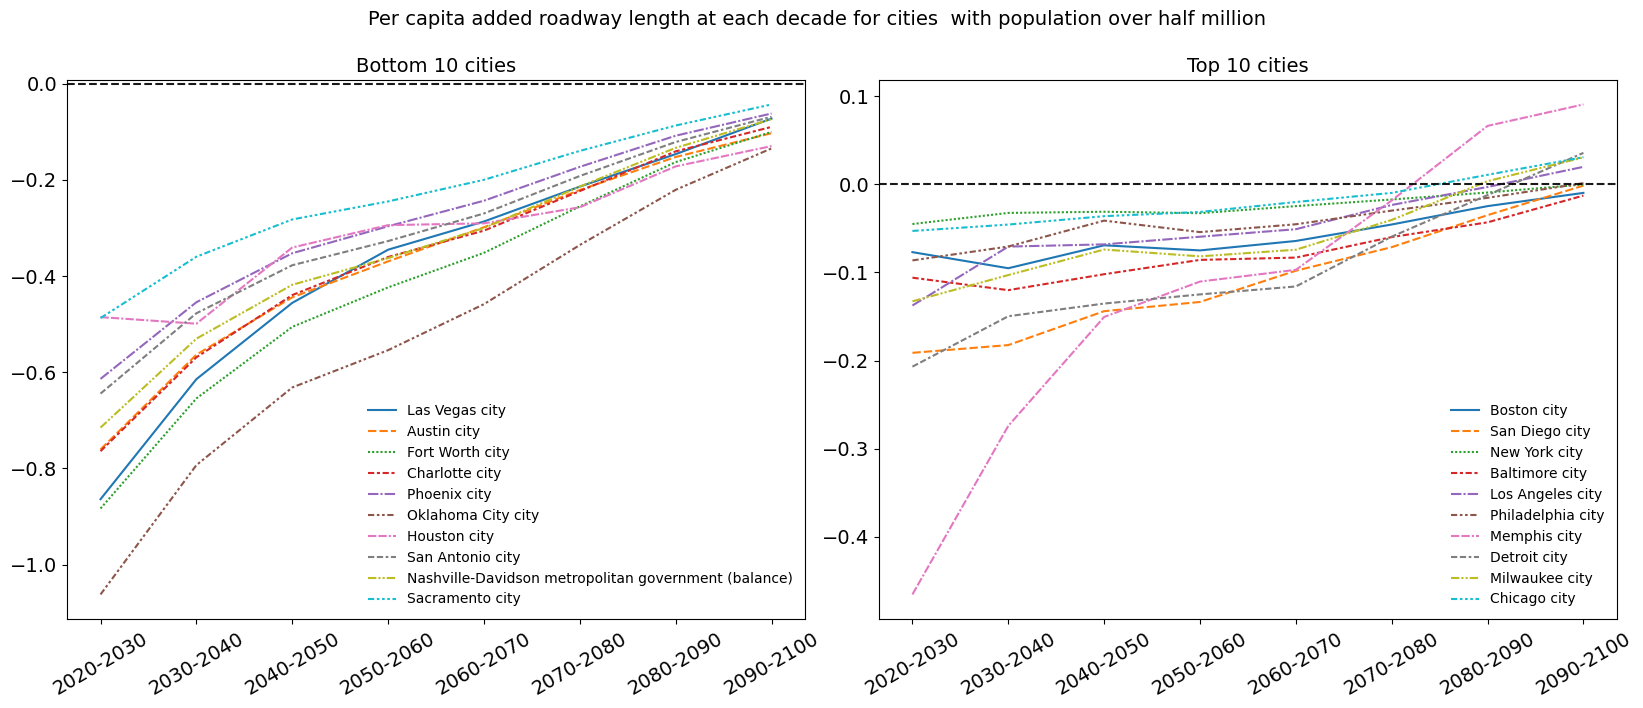

In [ ]:
roads_df_sorted = roads_df[roads_df['CensusPop_20'] > 500000].sort_values(by ='percent change from 2020-2100')[['NAMELSAD', 'per cap added from 2020-2030', 'per cap added from 2030-2040',
       'per cap added from 2040-2050', 'per cap added from 2050-2060', 'per cap added from 2060-2070', 'per cap added from 2070-2080',
       'per cap added from 2080-2090', 'per cap added from 2090-2100']]

lower_10 = roads_df_sorted.head(10).set_index('NAMELSAD') 
upper_10 = roads_df_sorted.tail(10).set_index('NAMELSAD') 

df_lineplot = [lower_10.T, upper_10.T]
fig, axes = plt.subplots(1, 2, sharex=True, figsize=(20,7))
fig.suptitle('Per capita added roadway length at each decade for cities  with population over half million', fontsize= 14)
axes[0].set_title('Bottom 10 cities', fontsize= 14)
axes[1].set_title('Top 10 cities', fontsize= 14)
for ax , df in zip(axes, df_lineplot):
    sns.lineplot(ax= ax, data=df, legend = 'brief')
    # sns.move_legend(ax, loc = 2, bbox_to_anchor=(1, 1))
    ax.axhline(y=0, color = 'black', alpha = 0.9,linestyle= '--')
    ax.set_xticks(range(len(df)), ['2020-2030', '2030-2040','2040-2050','2050-2060','2060-2070','2070-2080','2080-2090','2090-2100'],rotation = 30)
    ax.tick_params(labelsize= 14)
    ax.legend(frameon=False)
plt.rc('legend',fontsize=14) 
plt.subplots_adjust(wspace=0.1, hspace=0.1)

# fig.savefig(figure_filepath + 'Per capita added roadway length at each decade for cities  with population over half million' + '.png', dpi = 300,  bbox_inches='tight')

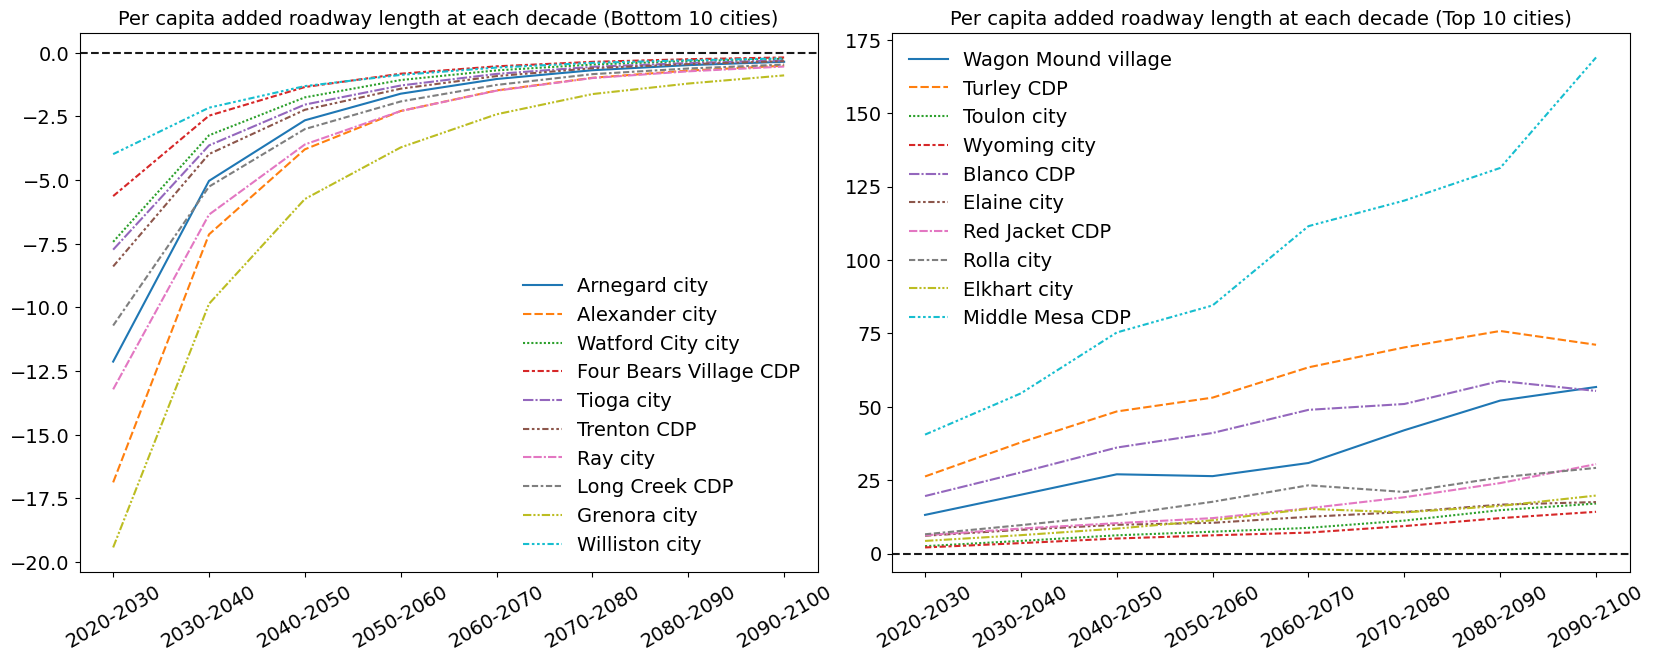

In [ ]:
import seaborn as sns
roads_df_sorted = roads_df[roads_df['CensusPop_20'] > 100].sort_values(by ='percent change from 2020-2100')[['NAMELSAD', 'per cap added from 2020-2030', 'per cap added from 2030-2040',
       'per cap added from 2040-2050', 'per cap added from 2050-2060', 'per cap added from 2060-2070', 'per cap added from 2070-2080',
       'per cap added from 2080-2090', 'per cap added from 2090-2100']]

lower_10 = roads_df_sorted.head(10).set_index('NAMELSAD') 
upper_10 = roads_df_sorted.tail(10).set_index('NAMELSAD') 

df_lineplot = [lower_10.T, upper_10.T]
fig, axes = plt.subplots(1, 2, sharex=True, figsize=(20,7))
# fig.suptitle('Top 10 cities with minimum and maximum percent change in per capita roadway')
axes[0].set_title('Per capita added roadway length at each decade (Bottom 10 cities)', fontsize= 14)
axes[1].set_title('Per capita added roadway length at each decade (Top 10 cities)', fontsize= 14)
for ax , df in zip(axes, df_lineplot):
    sns.lineplot(ax= ax, data=df, legend = 'brief')
    # sns.move_legend(ax, loc = 2, bbox_to_anchor=(1, 1))
    ax.axhline(y=0, color = 'black', alpha = 0.9,linestyle= '--')
    ax.set_xticks(range(len(df)), ['2020-2030', '2030-2040','2040-2050','2050-2060','2060-2070','2070-2080','2080-2090','2090-2100'],rotation = 30)
    ax.tick_params(labelsize= 14)
    ax.legend(frameon=False)
plt.rc('legend',fontsize=14) 
plt.subplots_adjust(wspace=0.1, hspace=0.1)

# fig.savefig(figure_filepath + 'Per capita added roadway length at each decade with population over 100' + '.png', dpi = 300,  bbox_inches='tight')

### starting from zero

In [ ]:
roads_df = roads_df.assign(**roads_df[['per_cap_mass_at_2020', 'per_cap_mass_at_2030', 'per_cap_mass_at_2040', 'per_cap_mass_at_2050', 
'per_cap_mass_at_2060', 'per_cap_mass_at_2070', 'per_cap_mass_at_2080', 'per_cap_mass_at_2090', 'per_cap_mass_at_2100']].sub(roads_df['per_cap_mass_at_2020'], axis=0).add_prefix('sub_'))

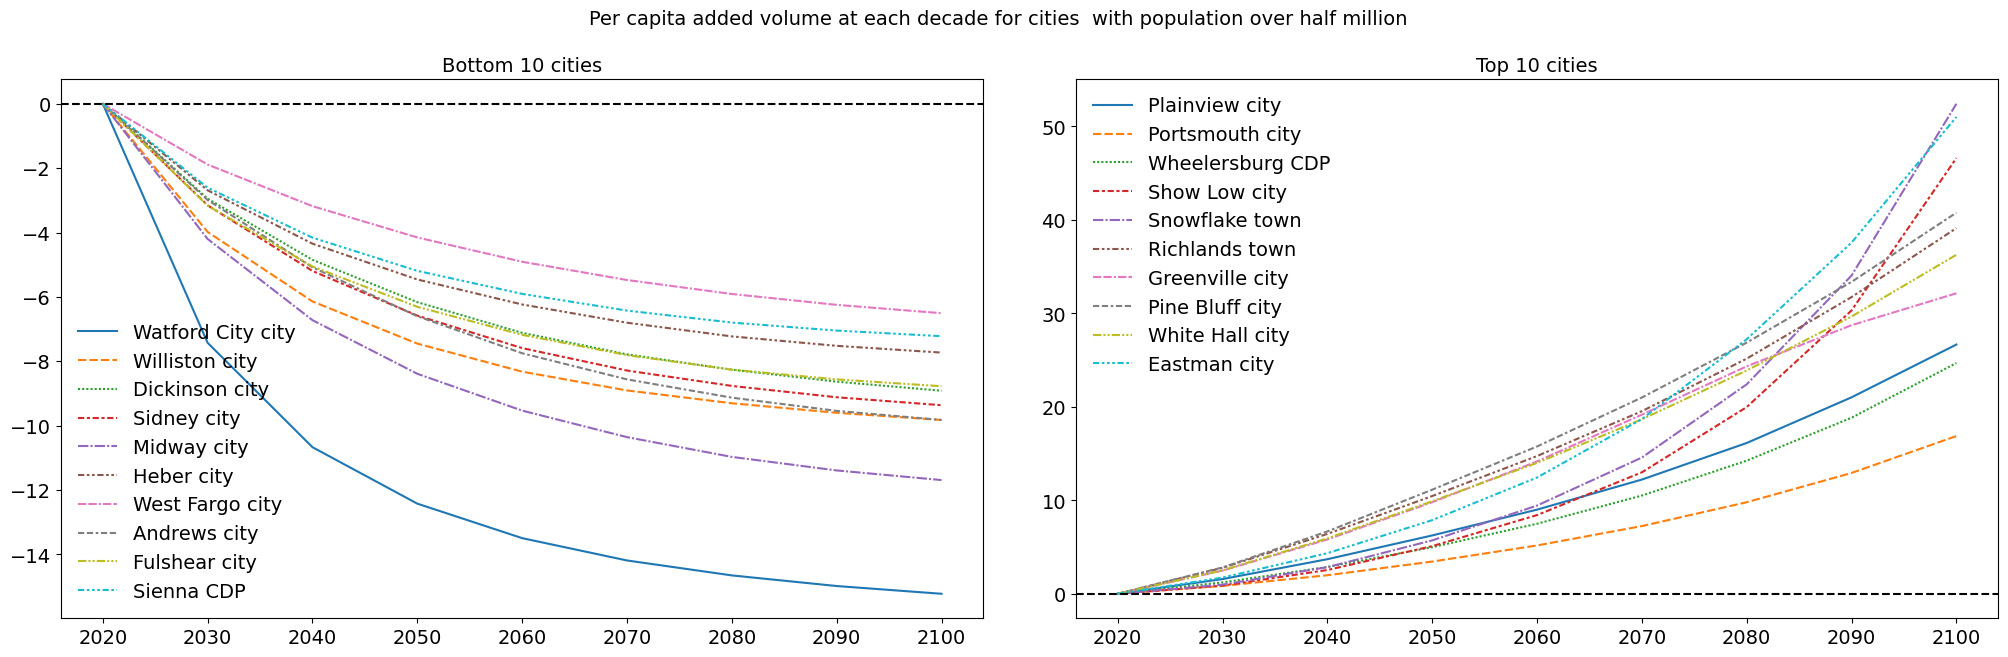

In [ ]:
roads_df_sorted = roads_df[roads_df['CensusPop_20'] > 5000].sort_values(by ='percent change from 2020-2100')[['NAMELSAD', 
        'sub_per_cap_mass_at_2020', 'sub_per_cap_mass_at_2030',
       'sub_per_cap_mass_at_2040', 'sub_per_cap_mass_at_2050',
       'sub_per_cap_mass_at_2060', 'sub_per_cap_mass_at_2070',
       'sub_per_cap_mass_at_2080', 'sub_per_cap_mass_at_2090',
       'sub_per_cap_mass_at_2100']]

# building_df_sorted = building_clean[building_clean['CensusPop_20'] > 500000].sort_values(by ='percent change from 2020-2100')[['NAMELSAD', 'per_cap_mass_at_2020', 
#                                     'per_cap_mass_at_2030',  'per_cap_mass_at_2040',  'per_cap_mass_at_2050',  'per_cap_mass_at_2060', 
#                                     'per_cap_mass_at_2070',  'per_cap_mass_at_2080',  'per_cap_mass_at_2090',  'per_cap_mass_at_2100',]]

lower_10 = roads_df_sorted.head(10).set_index('NAMELSAD') 
upper_10 = roads_df_sorted.tail(10).set_index('NAMELSAD') 

df_lineplot = [lower_10.T, upper_10.T]
fig, axes = plt.subplots(1, 2, sharex=True, figsize=(25,7))
fig.suptitle('Per capita added volume at each decade for cities  with population over half million', fontsize= 14)
axes[0].set_title('Bottom 10 cities', fontsize= 14)
axes[1].set_title('Top 10 cities', fontsize= 14)
for ax , df in zip(axes, df_lineplot):
    sns.lineplot(ax= ax, data=df, legend = True)
    # sns.move_legend(ax, loc = 2, bbox_to_anchor=(1, 1))
    ax.axhline(y=0, color = 'black', alpha = 1,linestyle= '--')
    ax.set_xticks(range(len(df)), ['2020', '2030','2040','2050','2060','2070','2080','2090', '2100']) #,rotation = 30)
    ax.tick_params(labelsize= 14)
    ax.legend(frameon=False)
plt.rc('legend',fontsize=14) 
plt.subplots_adjust(wspace=0.1, hspace=0.1)

In [ ]:
roads_df[['per_cap_mass_at_2020', 'per_cap_mass_at_2030', 'per_cap_mass_at_2060', 'per_cap_mass_at_2100', 'percent change from 2060-2100', 'percent change from 2020-2060']].sort_values(by ='percent change from 2060-2100')
roads_df['Percentile Rank'] = roads_df['percent change from 2020-2060'].rank(pct = True) 

roads_df['city_type_pct_rank'] = roads_df.groupby('city type')['percent change from 2020-2060'].rank(pct=True)

In [ ]:
# figure_filepath = r'D:\Work\Box Sync\Quantify Infrastructure\Figures\\'

# # # Import cartographic base maps: Cartographic boundary for plotting
# US_counties_cb = gpd.read_file(r'D:\Work\Box Sync\Trends_all states\Maps_2020\cb_2020_us_county_5m.zip') # tl_2020_us_county
# US_states_cb = gpd.read_file(r'D:\Work\Box Sync\Trends_all states\Maps_2020\cb_2020_us_state_5m.zip')  # tl_2020_us_state
# # source: https://gis.stackexchange.com/questions/141580/which-projection-is-best-for-mapping-the-contiguous-united-states
# US_states_cb = US_states_cb.to_crs('EPSG:9311')
# US_counties_cb = US_counties_cb.to_crs('EPSG:9311')

# import matplotlib

# import matplotlib
# def quantile_map_plot(df, list_of_columns, colors = 'viridis', is_county = False, state_code =None, file_path= None, file_name= None):

#     colors = colors
#     cmap = matplotlib.colors.ListedColormap([t[1] for t in sorted(colors.items())]) #Sorting by keys before converting to list


#     if len(list_of_columns) > 1:
        
#         fig, axes = plt.subplots(nrows=1, ncols=len(list_of_columns), figsize=(22,16)) #18,16 #len(list_of_columns)

#         for ax, col in zip(axes.flatten(), list_of_columns):
#             continental_ax = ax

#             if is_county==True:
#                 color_subset = {key: value for key, value in colors.items() if key in  sorted(df[df['STATEFP'] == state_code][col].unique())}
#                 cmap = matplotlib.colors.ListedColormap([t[1] for t in sorted(color_subset.items())])
#                 US_counties_cb[US_counties_cb['STATEFP'] == state_code].plot(ax=continental_ax, facecolor = 'none', edgecolor='gray', linewidth=0.3)
#                 df[df['STATEFP'] == state_code].plot(ax= continental_ax, column = col, legend = True, linewidth=0.1, legend_kwds={'loc': 'lower left'}, 
#                             cmap = cmap)
                
#             else:
#                 # Set bounds to fit desired areas in each plot
#                 continental_ax.set_xlim(-2257388.37, 2695859.75)
#                 continental_ax.set_ylim(-2546944.04, 808080.90)

#                 # hawaii_ax = ax.inset_axes([.20, .01, .25, .2])

#                 US_states_cb.plot(ax=continental_ax, facecolor = 'none', edgecolor='gray', linewidth=0.3)
#                 df.plot(ax= continental_ax, column = col, legend = True, linewidth=0.1, legend_kwds={'loc': 'lower left'}, cmap = cmap)
            
#                 # US_states_cb[US_states_cb['STATEFP'] == '15'].plot(facecolor = 'none', edgecolor='gray', linewidth=0.2, ax=hawaii_ax)
#                 # print(df_map[df_map['STATEFP'] == '15'][col].unique())
#                 # df_map[df_map['STATEFP'] == '15'].plot(column=col, cmap = matplotlib.colors.ListedColormap(['orange', 'purple']), 
#                 #                             ax=hawaii_ax,  linewidth=0.3, missing_kwds = dict(color='black'))

#             ax.set_title(col)
#             # remove ticks
#             for ax in [continental_ax]: #, hawaii_ax]:
#                 ax.set_yticks([])
#                 ax.set_xticks([])
#                 ax.axis('off')
#                 plt.tight_layout()
#                 plt.axis('off') 
#     else:
#         fig, continental_ax = plt.subplots(figsize=(16,22)) #18,16
#         col = list_of_columns
#         US_counties_cb.plot(ax=continental_ax, facecolor = 'none', edgecolor='gray', linewidth=0.3)
#         df.plot(ax= continental_ax, column = col, legend = True, linewidth=0.4, legend_kwds={'loc': 'lower left'}, 
#                         cmap = cmap)
#         continental_ax.axis('off')



In [ ]:
# os.environ['USE_PYGEOS'] = '0'
# # Import places map
# places_US = gpd.read_file(r'D:\Work\Box Sync\Quantify Infrastructure\MapData\all_places\compiled.shp')
# print(places_US.shape)

# places_50_states = places_US[(places_US['STATEFP'] != '02') & (places_US['STATEFP'] != '60') & (places_US['STATEFP'] != '66') & (places_US['STATEFP'] != '69') & (places_US['STATEFP'] != '72') & (places_US['STATEFP'] != '78')]

# print(places_50_states.shape, roads_df.shape)

In [ ]:
# df_map = places_50_states.merge(roads_df, on =['GEOID', 'NAMELSAD'])
# print(df_map.shape)

# df_map = df_map.to_crs('EPSG:9311')
# df_map.columns

In [ ]:
# # Function to categorize values based on quartile range
# def categorize_by_quartiles(grouped_df, target_column):
#     # Calculate quartile values
#     Q1 = grouped_df.quantile(0.25)
#     Q3 = grouped_df.quantile(0.75)

#     # Categorize values based on quartiles
#     def categorize_value(value):
#         if value < Q1:
#             return 'Pressurized'
#         elif value > Q3:
#             return 'Oversized'
#         else:
#             return 'Balanced'

#     # Apply categorization to target_column
#     return target_column.apply(categorize_value)

### Add landuse data from 2019

In [ ]:
df_nlcd = pd.read_csv(r'D:\Work\Box Sync\Quantify Infrastructure\GEE_NLCD_landuse\LandCoverbyCity19.csv')
df_nlcd['GEOID'] = df_nlcd['GEOID'].astype(str).str.rjust(7,'0')

column_names = ['Open_water', 'Perennial_ice_snow', 'Developed_open_space','Developed_low_intensity', 'Developed_medium_intensity',
       'Developed_high_intensity', 'Barren_land', 'Deciduous_forest', 'Evergreen_forest', 'Mixed_forest', 'Dwarf_scrub', 'Shrub_scrub',
       'Grassland_herbaceous', 'Sedge_herbaceous', 'Lichens', 'Moss', 'Pasture_hay', 'Cultivated_crops', 'Woody_wetland', 'EmergentherbaceousWetlands']

df_nlcd[column_names] = df_nlcd[column_names].div(df_nlcd[column_names].sum(axis=1), axis=0).multiply(100)
df_nlcd = df_nlcd.fillna(0)

df_nlcd['veg_wetland'] = df_nlcd[['Dwarf_scrub', 'Shrub_scrub', 'Grassland_herbaceous', 'Sedge_herbaceous', 'Lichens', 'Moss',
       'Pasture_hay', 'Cultivated_crops', 'Woody_wetland', 'EmergentherbaceousWetlands', 'Perennial_ice_snow']].sum(axis=1)
df_nlcd['forest'] = df_nlcd[['Deciduous_forest','Evergreen_forest', 'Mixed_forest']].sum(axis=1)

In [ ]:
roads_df_lu = roads_df.merge(df_nlcd[['GEOID', 'Open_water','veg_wetland', 'forest', 'Barren_land', 'Developed_open_space', 
'Developed_low_intensity', 'Developed_medium_intensity', 'Developed_high_intensity']], on ='GEOID')

roads_df_lu['otherLU'] = roads_df_lu[['Open_water','veg_wetland', 'forest', 'Barren_land']].sum(axis=1)
roads_df_lu['developedLU'] = roads_df_lu[['Developed_open_space','Developed_low_intensity', 'Developed_medium_intensity', 'Developed_high_intensity']].sum(axis=1)

In [ ]:
roads_df_lu[(roads_df_lu['developedLU'] ==100)][['State', 'CensusPop_20', 'ssp22060', 'city type','weighted_HU_density_sqmi', 'NAMELSAD','road_area_m2',
                                                 'per_cap_mass_at_2020', 'per_cap_mass_at_2060', 
                                         'otherLU', 'developedLU','REGION','median_income']].sort_values(by ='per_cap_mass_at_2020' ).tail(20)

,State,CensusPop_20,ssp22060,city type,weighted_HU_density_sqmi,NAMELSAD,road_area_m2,per_cap_mass_at_2020,per_cap_mass_at_2060,otherLU,developedLU,REGION,median_income
23420,42.0,1445.0,1265.439238,suburban,815.039326,Faxon CDP,170078.170872,12.200872,13.936965,0.0,100.0,Northeast,71630.0
25538,48.0,4385.0,6947.571055,suburban,879.730028,Hunters Creek Village city,493625.562469,12.280428,8.140048,0.0,100.0,South,250001.0
14487,29.0,366.0,510.277320,suburban,1520.017296,Oakview village,42184.839245,12.352300,9.448280,0.0,100.0,Midwest,72500.0
14373,29.0,1390.0,1618.064126,suburban,1232.705840,Oakland city,173521.255136,12.677754,11.128777,0.0,100.0,Midwest,108958.0
25536,48.0,2370.0,3754.313076,suburban,1268.009308,Hedwig Village city,326194.796404,13.614347,9.096196,0.0,100.0,South,152768.0
7768,18.0,854.0,860.324194,suburban,279.213242,Roseland town,121630.984866,13.672051,13.618902,0.0,100.0,Midwest,31736.0
12071,26.0,4088.0,5119.539671,suburban,1010.313526,Lathrup Village city,515623.790613,13.871167,11.353427,0.0,100.0,Midwest,97083.0
26919,48.0,161.0,167.569418,rural,84.220385,Lago CDP,20208.327273,13.946396,13.392145,0.0,100.0,South,2499.0
27064,48.0,49.0,59.508281,periurban,58.298119,Olivia Lopez de Gutierrez CDP,7041.380144,15.966848,13.489681,0.0,100.0,South,NaN
3257,8.0,254.0,363.219600,suburban,1882.840552,Garden City town,40543.117848,18.143050,13.675576,0.0,100.0,West,38281.0


In [56]:
roads_df_lu['road_land_ratio'] = roads_df_lu['road_area_m2']/roads_df_lu['ALAND']

KeyError: 'ALAND'

In [ ]:
roads_df_lu[['NAMELSAD','road_area_m2', 'ALAND', 'road_land_ratio', 'per_cap_mass_at_2020','per_cap_mass_at_2040', 'per_cap_mass_at_2060','per_cap_mass_at_2100','cl_total_length','surface_Res_at_2080',
                                           'otherLU','developedLU', 'median_income']].sort_values('road_land_ratio').tail(20)

,NAMELSAD,road_area_m2,ALAND,road_land_ratio,per_cap_mass_at_2020,per_cap_mass_at_2040,per_cap_mass_at_2060,per_cap_mass_at_2100,cl_total_length,surface_Res_at_2080,otherLU,developedLU,median_income
23496,Harrison City CDP,29817.261385,126641,0.235447,18.119839,17.762890,17.866833,18.605548,3152.852054,3162.943183,23.745613,76.254387,NaN
14458,Collins village,150570.291476,639234,0.235548,120.859137,130.236139,142.522567,171.674910,15107.392092,15107.392092,15.498325,84.501675,34931.0
7976,New Middletown town,21347.224285,90394,0.236158,24.841662,25.120884,27.601959,37.262644,2235.749571,2235.758639,28.270855,71.729145,56000.0
28127,Dunbar CDP,14080.032875,59469,0.236763,19.803140,24.832509,32.592669,60.171081,1564.448097,1564.448097,1.552703,98.447297,NaN
20682,Cynthiana CDP,21405.040315,88817,0.241002,40.023874,47.528350,58.496431,95.056700,2281.360803,2281.360803,8.425817,91.574183,NaN
19718,Ithaca village,19610.066787,80879,0.242462,25.143091,26.797242,29.949858,39.165200,2036.590376,2036.590376,5.659664,94.340336,NaN
22600,Coaldale borough,21329.388198,87374,0.244116,18.283724,19.859908,22.366498,29.918822,2303.749273,2303.749273,17.289784,82.710216,22500.0
2274,Carrick CDP,37571.502108,152301,0.246692,24.690820,27.370444,29.670481,34.958290,3530.787241,3530.787241,17.142589,82.857411,NaN
23939,Tharptown (Uniontown) CDP,62599.200097,252773,0.247650,15.430705,16.736644,18.328667,22.771980,7514.753365,7514.753365,5.644218,94.355782,53448.0
27066,Olmito and Olmito CDP,18142.623062,72264,0.251060,7.303794,6.479394,6.042564,5.992254,2015.847007,2025.381966,0.148130,99.851870,38162.0


In [ ]:
np.max(roads_df_lu['cl_total_length']*1000/roads_df_lu['ALAND']), np.mean(roads_df_lu['cl_total_length']*1000/roads_df_lu['ALAND'])

(38.670350137575234, 6.6164758456974795)

In [ ]:
roads_df_lu[['State', 'NAMELSAD','road_land_ratio', 'per_cap_mass_at_2020','per_cap_mass_at_2040', 'per_cap_mass_at_2060','per_cap_mass_at_2100','cl_total_length','surface_Res_at_2080',
                                           'otherLU','developedLU']].sort_values('per_cap_mass_at_2100').tail(10)

,State,NAMELSAD,road_land_ratio,per_cap_mass_at_2020,per_cap_mass_at_2040,per_cap_mass_at_2060,per_cap_mass_at_2100,cl_total_length,surface_Res_at_2080,otherLU,developedLU
15187,30.0,Niarada CDP,0.007524,3544.178933,3428.599499,3430.892260,3554.337300,9.923701e+04,9.949588e+04,98.578868,1.421132
19501,38.0,Calio city,0.015031,4310.472237,3870.958048,3896.121026,3561.115455,3.448378e+04,3.548494e+04,95.349652,4.650348
9256,20.0,Greeley County unified government (balance),0.008201,4416.076010,4312.771079,4129.161574,3852.262465,1.810591e+06,1.813679e+06,97.235616,2.764384
14340,29.0,River Bend village,0.034819,4801.610049,3751.120383,3803.644530,3901.202969,1.440483e+04,1.555279e+04,81.844663,18.155337
27561,49.0,Halls Crossing CDP,0.004650,3878.888274,3878.888274,3923.942444,3962.139086,1.551555e+04,1.576071e+04,98.503283,1.496717
2887,6.0,Pearsonville CDP,0.018046,2521.872144,2521.872144,2882.139593,4034.995430,2.017498e+04,2.017498e+04,92.623828,7.376172
17104,35.0,Newkirk CDP,0.058499,1830.849121,2092.398995,2929.358593,4882.264322,1.464679e+04,1.464679e+04,87.742151,12.257849
2639,6.0,Johnsville CDP,0.014144,2533.551662,3096.563142,3715.875771,5067.103324,5.573814e+04,5.573814e+04,99.769122,0.230878
2239,6.0,Bucks Lake CDP,0.017870,2299.477922,3372.567619,4598.955844,8431.419047,5.058851e+04,5.058851e+04,96.174537,3.825463
3163,6.0,Warner Valley CDP,0.003637,2212.791677,2950.388902,4425.583353,8851.166707,1.770233e+04,1.770233e+04,99.887838,0.112162


In [ ]:
roads_df_lu[['State','NAMELSAD','road_land_ratio','CensusPop_20', 'per_cap_mass_at_2020','per_cap_mass_at_2040', 'per_cap_mass_at_2060','per_cap_mass_at_2100','cl_total_length','surface_Res_at_2080',
                                           'otherLU','developedLU']].sort_values('per_cap_mass_at_2020').tail(10)

,State,NAMELSAD,road_land_ratio,CensusPop_20,per_cap_mass_at_2020,per_cap_mass_at_2040,per_cap_mass_at_2060,per_cap_mass_at_2100,cl_total_length,surface_Res_at_2080,otherLU,developedLU
24917,46.0,Okaton CDP,0.010046,31.0,2226.728414,2654.945417,3001.242645,1970.602985,6.902858e+04,6.977383e+04,97.318445,2.681555
2239,6.0,Bucks Lake CDP,0.017870,22.0,2299.477922,3372.567619,4598.955844,8431.419047,5.058851e+04,5.058851e+04,96.174537,3.825463
2887,6.0,Pearsonville CDP,0.018046,8.0,2521.872144,2521.872144,2882.139593,4034.995430,2.017498e+04,2.017498e+04,92.623828,7.376172
2639,6.0,Johnsville CDP,0.014144,22.0,2533.551662,3096.563142,3715.875771,5067.103324,5.573814e+04,5.573814e+04,99.769122,0.230878
15187,30.0,Niarada CDP,0.007524,28.0,3544.178933,3428.599499,3430.892260,3554.337300,9.923701e+04,9.949588e+04,98.578868,1.421132
27561,49.0,Halls Crossing CDP,0.004650,4.0,3878.888274,3878.888274,3923.942444,3962.139086,1.551555e+04,1.576071e+04,98.503283,1.496717
19501,38.0,Calio city,0.015031,8.0,4310.472237,3870.958048,3896.121026,3561.115455,3.448378e+04,3.548494e+04,95.349652,4.650348
9256,20.0,Greeley County unified government (balance),0.008201,410.0,4416.076010,4312.771079,4129.161574,3852.262465,1.810591e+06,1.813679e+06,97.235616,2.764384
14340,29.0,River Bend village,0.034819,3.0,4801.610049,3751.120383,3803.644530,3901.202969,1.440483e+04,1.555279e+04,81.844663,18.155337
4031,12.0,Bay Lake city,0.030930,29.0,5964.395265,4426.554606,3660.891516,2877.340088,1.729675e+05,1.807100e+05,64.618353,35.381647


In [ ]:
roads_df_lu[['State', 'NAMELSAD','road_land_ratio', 'CensusPop_20','per_cap_mass_at_2020','per_cap_mass_at_2040', 'per_cap_mass_at_2060','per_cap_mass_at_2100','total_length', 'cl_total_length','surface_Res_at_2080',
                                           'otherLU','developedLU']].sort_values('per_cap_mass_at_2020').head(10)

,State,NAMELSAD,road_land_ratio,CensusPop_20,per_cap_mass_at_2020,per_cap_mass_at_2040,per_cap_mass_at_2060,per_cap_mass_at_2100,total_length,cl_total_length,surface_Res_at_2080,otherLU,developedLU
3068,6.0,Stevenson Ranch CDP,0.003533,20178.0,0.225636,0.202382,0.197285,0.216579,4552.877561,4552.877561,4568.519983,42.053592,57.946408
2522,6.0,Hacienda Heights CDP,0.004471,54191.0,0.230077,0.200462,0.186216,0.181568,21350.088433,12468.106324,12515.326026,22.136329,77.863671
2746,6.0,Marina del Rey CDP,0.009259,11373.0,0.235208,0.226762,0.222662,0.235411,3966.592534,2675.019991,2984.772481,29.138464,70.861536
2653,6.0,Lake Los Angeles CDP,0.001236,13187.0,0.241230,0.217150,0.212354,0.234295,6362.212455,3181.106228,3192.736223,56.142708,43.857292
1911,6.0,Baldwin Park city,0.009921,72176.0,0.250262,0.218084,0.202595,0.197576,31503.472642,18062.919724,18127.176341,3.158485,96.841515
2132,6.0,Agua Dulce CDP,0.000165,3451.0,0.315242,0.288284,0.279932,0.293177,2175.797065,1087.898533,1093.844065,81.444771,18.555229
3055,6.0,South Whittier CDP,0.011462,56415.0,0.320479,0.279446,0.259750,0.253484,31163.758746,18079.812852,18146.416299,0.624326,99.375674
2973,6.0,Rowland Heights CDP,0.004941,48231.0,0.337155,0.291308,0.268979,0.259124,22916.359191,16261.342442,16328.953034,41.735513,58.264487
3145,6.0,Val Verde CDP,0.001207,2399.0,0.341149,0.306947,0.299226,0.327141,1636.831381,818.415691,824.068329,81.046811,18.953189
2417,6.0,East Whittier CDP,0.013649,10394.0,0.422462,0.365492,0.337549,0.325095,8191.087533,4391.075099,4422.472142,1.488420,98.511580


In [ ]:
import pandas as pd


def gini_coefficient(values):
    sorted_values = sorted(values)
    n = len(values)
    coef = 0
    for i, x in enumerate(sorted_values):
        coef += (i + 1) * x
    coef = 2 * coef / (n * sum(sorted_values)) - (n + 1) / n
    return coef

column_names = ['per_cap_mass_at_2020','per_cap_mass_at_2030','per_cap_mass_at_2040', 'per_cap_mass_at_2050','per_cap_mass_at_2060',
                'per_cap_mass_at_2070', 'per_cap_mass_at_2080','per_cap_mass_at_2090','per_cap_mass_at_2100']

gini_values = []
# Calculate Gini coefficient for each variable
for col in column_names:
    df = roads_df_lu
    threshold_u = df[col].quantile(0.9)
    df = df[df[col] < threshold_u]
    gini = gini_coefficient(df[col])
    print(gini)
    gini_values.append(gini)

0.3646031119676103
0.37302561268936385
0.38250439681298976
0.39218111671583333
0.4011915297196773
0.41033206819511103
0.4194437900633996
0.42817937080962154
0.43682733686548736


In [ ]:
# roads_df_lu.columns[100:]

In [58]:
roads_perCap = roads_df_lu.rename(columns={'per_cap_mass_at_2020': 'length_m_perCap_2020','per_cap_mass_at_2030': 'length_m_perCap_2030', 'per_cap_mass_at_2040': 'length_m_perCap_2040', 
                            'per_cap_mass_at_2050': 'length_m_perCap_2050', 'per_cap_mass_at_2060': 'length_m_perCap_2060', 'per_cap_mass_at_2070': 'length_m_perCap_2070', 
                            'per_cap_mass_at_2080': 'length_m_perCap_2080', 'per_cap_mass_at_2090': 'length_m_perCap_2090', 'per_cap_mass_at_2100': 'length_m_perCap_2100',})

roads_perCap[['GEOID', 'NAMELSAD','length_m_perCap_2020','length_m_perCap_2030', 'length_m_perCap_2040', 'length_m_perCap_2050', 'length_m_perCap_2060', 
              'length_m_perCap_2070', 'length_m_perCap_2080', 'length_m_perCap_2090', 'length_m_perCap_2100','label','future trend from SSP 2','weighted_HU_density_sqmi', 'median_income',
               'Developed_low_intensity', 'Developed_medium_intensity', 'Developed_high_intensity', 'otherLU', 'developedLU', 
               'road_land_ratio', 'citytype_at_2030', 'citytype_at_2040', 'citytype_at_2050', 'citytype_at_2060', 'citytype_at_2070', 'citytype_at_2080', 'citytype_at_2090',
                 'citytype_at_2100']].to_csv(r'D:\Work\Box Sync\Quantify Infrastructure\output_csvs\roads_perCap_ssp2.csv')

In [ ]:
roads_df_lu[roads_df_lu['NAMELSAD']== 'Stone Park village'][['city type', 'weighted_HU_density_sqmi', 'median_income']]

,city type,weighted_HU_density_sqmi,median_income
6952,urban,4116.083354,63710.0


In [ ]:
roads_df_lu[['GEOID', 'NAMELSAD','cl_total_length', 'surface_Res_at_2040', 'total_length','per_cap_mass_at_2020','per_cap_mass_at_2030','per_cap_mass_at_2040', 'per_cap_mass_at_2050','per_cap_mass_at_2060',
              ]].sort_values(by = 'per_cap_mass_at_2020',)

,GEOID,NAMELSAD,cl_total_length,surface_Res_at_2040,total_length,per_cap_mass_at_2020,per_cap_mass_at_2030,per_cap_mass_at_2040,per_cap_mass_at_2050,per_cap_mass_at_2060
3068,0674130,Stevenson Ranch CDP,4.552878e+03,4.566339e+03,4.552878e+03,0.225636,0.210891,0.202382,0.198483,0.197285
2522,0631596,Hacienda Heights CDP,1.246811e+04,1.250043e+04,2.135009e+04,0.230077,0.212369,0.200462,0.192388,0.186216
2746,0645806,Marina del Rey CDP,2.675020e+03,2.905275e+03,3.966593e+03,0.235208,0.230781,0.226762,0.224220,0.222662
2653,0639612,Lake Los Angeles CDP,3.181106e+03,3.191230e+03,6.362212e+03,0.241230,0.225894,0.217150,0.213343,0.212354
1911,0603666,Baldwin Park city,1.806292e+04,1.810859e+04,3.150347e+04,0.250262,0.231023,0.218084,0.209298,0.202595
...,...,...,...,...,...,...,...,...,...,...
27561,4933027,Halls Crossing CDP,1.551555e+04,1.551555e+04,3.103111e+04,3878.888274,3878.888274,3878.888274,3923.942444,3923.942444
19501,3811580,Calio city,3.448378e+04,3.483862e+04,6.896756e+04,4310.472237,4335.834348,3870.958048,3882.851650,3896.121026
9256,2028412,Greeley County unified government (balance),1.810591e+06,1.811364e+06,3.629253e+06,4416.076010,4363.897428,4312.771079,4253.007919,4129.161574
14340,2962056,River Bend village,1.440483e+04,1.500448e+04,1.827588e+04,4801.610049,4861.560183,3751.120383,3778.545402,3803.644530


### Check quantiles after dropping outliers (extreme values)

In [ ]:
# Function to remove outliers using IQR method and recalculate quantiles for a specific column
def remove_outliers_and_recalculate_quantiles_for_column(df, column_name):
    # Extract the specified column
    column = df[column_name]
    print("Initial dataframe shape", df.shape)

    # Calculate IQR
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)
    IQR = Q3 - Q1
    print("quantile values before excluding outliers:")
    print(Q1.round(2), Q3.round(2))

    # Define lower and upper bounds for outliers
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filter DataFrame to exclude outliers
    df_filtered = df[(column >= lower_bound) & (column <= upper_bound)]

    # Recalculate quantile values after excluding outliers
    quantiles = df_filtered[column_name].quantile([0.25, 0.75])
    print("quantile values after excluding outliers:")
    print(quantiles)
    print("New dataframe shape", df_filtered.shape)
    print('\n')

    return df_filtered, quantiles

In [ ]:
df_filtered, quantiles = remove_outliers_and_recalculate_quantiles_for_column(df_map[df_map['city type'] == 'urban'], 'per_cap_mass_at_2020')
df_filtered, quantiles = remove_outliers_and_recalculate_quantiles_for_column(df_map[df_map['city type'] == 'suburban'], 'per_cap_mass_at_2020')
df_filtered, quantiles = remove_outliers_and_recalculate_quantiles_for_column(df_map[df_map['city type'] == 'periurban'], 'per_cap_mass_at_2020')
df_filtered, quantiles = remove_outliers_and_recalculate_quantiles_for_column(df_map[df_map['city type'] == 'rural'], 'per_cap_mass_at_2020')

Initial dataframe shape (312, 134)
quantile values before excluding outliers:
2.84 5.26
quantile values after excluding outliers:
0.25    2.819227
0.75    5.073500
Name: per_cap_mass_at_2020, dtype: float64
New dataframe shape (304, 134)


Initial dataframe shape (6885, 134)
quantile values before excluding outliers:
7.81 16.02
quantile values after excluding outliers:
0.25     7.637311
0.75    14.888575
Name: per_cap_mass_at_2020, dtype: float64
New dataframe shape (6499, 134)


Initial dataframe shape (5697, 134)
quantile values before excluding outliers:
9.14 20.12
quantile values after excluding outliers:
0.25     8.936731
0.75    18.783917
Name: per_cap_mass_at_2020, dtype: float64
New dataframe shape (5375, 134)


Initial dataframe shape (17639, 134)
quantile values before excluding outliers:
22.04 57.86
quantile values after excluding outliers:
0.25    21.175695
0.75    48.697344
Name: per_cap_mass_at_2020, dtype: float64
New dataframe shape (16067, 134)




In [ ]:
roads_df_lu.groupby(['State', 'utilization_2020', 'utilization_2060','utilization_2100']).size().head(20)

State  utilization_2020  utilization_2060  utilization_2100
1.0    Balanced          Balanced          Balanced            175
                                           Oversized            57
                                           Pressurized           7
                         Oversized         Balanced              1
                                           Oversized            32
                         Pressurized       Pressurized          15
       Oversized         Balanced          Balanced             25
                                           Oversized             4
                         Oversized         Balanced              2
                                           Oversized           259
       Pressurized       Balanced          Balanced              3
                         Pressurized       Balanced              2
                                           Pressurized           9
4.0    Balanced          Balanced          Balanced            102
  

In [ ]:
roads_df_lu.groupby(['utilization_2020']).size(), roads_df_lu.groupby(['utilization_2080']).size(), roads_df_lu.groupby(['utilization_2100']).size()

(utilization_2020
 Balanced       15267
 Oversized       7633
 Pressurized     7633
 dtype: int64,
 utilization_2080
 Balanced       13192
 Oversized       8226
 Pressurized     9115
 dtype: int64,
 utilization_2100
 Balanced       12648
 Oversized       9150
 Pressurized     8735
 dtype: int64)

### Plot temporal shift

In [ ]:
# roads_clean[['city type','percent change from 2020-2040', 'percent change from 2040-2060', 'percent change from 2060-2080', 'percent change from 2080-2100']].describe()

In [ ]:
roads_clean[['GEOID', 'NAMELSAD', 'CensusPop_20',
       'city type', 'weighted_HU_density_sqmi', 'per_cap_mass_at_2020',
       'per_cap_mass_at_2030', 'surface_Res_at_2030', 'per_cap_mass_at_2040',
       'surface_Res_at_2040', 'per_cap_mass_at_2050', 'surface_Res_at_2050',
       'per_cap_mass_at_2060', 'surface_Res_at_2060',]].sort_values(by= 'per_cap_mass_at_2020',).tail(30)

,GEOID,NAMELSAD,CensusPop_20,city type,weighted_HU_density_sqmi,per_cap_mass_at_2020,per_cap_mass_at_2030,surface_Res_at_2030,per_cap_mass_at_2040,surface_Res_at_2040,per_cap_mass_at_2050,surface_Res_at_2050,per_cap_mass_at_2060,surface_Res_at_2060
10482,2252565,Mound village,12.0,rural,5.358973,1012.555580,1012.898896,1.215479e+04,1104.980613,1.215479e+04,1215.478675,1.215479e+04,1215.478675,1.215479e+04
2775,0647794,Mineral CDP,136.0,rural,2.284139,1034.390395,1049.829057,1.406771e+05,1090.520106,1.406771e+05,1143.716209,1.406771e+05,1192.178760,1.406771e+05
3125,0680515,Trona CDP,11.0,rural,0.302877,1057.471635,1060.397247,1.166437e+04,1060.397247,1.166437e+04,1060.397247,1.166437e+04,1063.063150,1.169369e+04
17120,3554500,Orogrande CDP,35.0,rural,0.033770,1115.312141,1148.115439,3.903592e+04,1182.906816,3.903592e+04,1219.872654,3.903592e+04,1219.872654,3.903592e+04
3635,0858960,Piedra CDP,31.0,rural,1.291587,1143.301836,1181.411897,3.544236e+04,1222.150238,3.544236e+04,1312.679886,3.544236e+04,1363.167574,3.544236e+04
17065,3545365,Lybrook CDP,19.0,rural,0.591612,1157.049492,1221.330019,2.198394e+04,1293.172961,2.198394e+04,1465.596023,2.198394e+04,1570.281453,2.198394e+04
1002,0478855,Valle CDP,759.0,rural,1.174059,1235.164307,1137.641211,9.385540e+05,1061.429295,9.393649e+05,993.737252,9.400754e+05,925.041459,9.407672e+05
22024,4106400,Biggs Junction CDP,5.0,rural,1.098816,1282.795126,1283.421644,6.417108e+03,1283.421644,6.417108e+03,1604.277055,6.417108e+03,1604.277055,6.417108e+03
14342,2922951,Evergreen village,20.0,rural,8.659477,1289.094118,1289.325405,2.578651e+04,1357.184636,2.578651e+04,1432.583783,2.578651e+04,1516.853417,2.578651e+04
30488,5644615,Lance Creek CDP,43.0,rural,0.497329,1298.671846,1271.802800,5.595932e+04,1194.359095,5.613488e+04,1127.095912,5.635480e+04,1029.484260,5.662163e+04


In [ ]:
# px_data = roads_clean[roads_clean['city type'] == 'urban'][['per_cap_mass_at_2020', 'per_cap_mass_at_2030', 'per_cap_mass_at_2040','per_cap_mass_at_2050', 'per_cap_mass_at_2060', 'per_cap_mass_at_2070',
#              'per_cap_mass_at_2080','per_cap_mass_at_2090', 'per_cap_mass_at_2100']]
# x = [2020, 2030, 2040, 2050, 2060, 2070, 2080, 2090, 2100] 
# y = px_data[['per_cap_mass_at_2020', 'per_cap_mass_at_2030', 'per_cap_mass_at_2040','per_cap_mass_at_2050', 'per_cap_mass_at_2060', 'per_cap_mass_at_2070',
#              'per_cap_mass_at_2080','per_cap_mass_at_2090', 'per_cap_mass_at_2100']].mean(axis=0).values

# import plotly.express as px
# df = px_data
# fig = px.scatter(px_data, x=px_data.index, y='per_cap_mass_at_2020')
# fig = px.scatter(px_data, x='per_cap_mass_at_2020', y='per_cap_mass_at_2080', color = 'per_cap_mass_at_2060')
# fig.show()

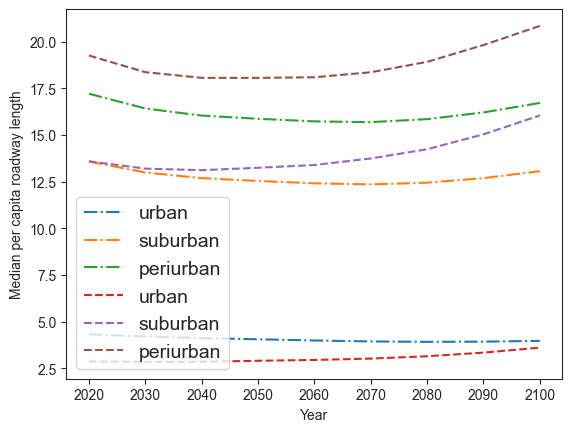

In [ ]:
x = [2020, 2030, 2040, 2050, 2060, 2070, 2080, 2090, 2100] 
y1 = roads_clean[roads_clean['city type'] == 'urban'][['per_cap_mass_at_2020', 'per_cap_mass_at_2030', 'per_cap_mass_at_2040','per_cap_mass_at_2050', 'per_cap_mass_at_2060',
                                                        'per_cap_mass_at_2070','per_cap_mass_at_2080','per_cap_mass_at_2090', 'per_cap_mass_at_2100']].mean(axis=0).values
y2 = roads_clean[roads_clean['city type'] == 'suburban'][['per_cap_mass_at_2020', 'per_cap_mass_at_2030', 'per_cap_mass_at_2040','per_cap_mass_at_2050', 'per_cap_mass_at_2060',
                                                        'per_cap_mass_at_2070','per_cap_mass_at_2080','per_cap_mass_at_2090', 'per_cap_mass_at_2100']].mean(axis=0).values
y3 = roads_clean[roads_clean['city type'] == 'periurban'][['per_cap_mass_at_2020', 'per_cap_mass_at_2030', 'per_cap_mass_at_2040','per_cap_mass_at_2050', 'per_cap_mass_at_2060',
                                                        'per_cap_mass_at_2070','per_cap_mass_at_2080','per_cap_mass_at_2090', 'per_cap_mass_at_2100']].mean(axis=0).values
y4 = roads_clean[roads_clean['city type'] == 'rural'][['per_cap_mass_at_2020', 'per_cap_mass_at_2030', 'per_cap_mass_at_2040','per_cap_mass_at_2050', 'per_cap_mass_at_2060',
                                                        'per_cap_mass_at_2070','per_cap_mass_at_2080','per_cap_mass_at_2090', 'per_cap_mass_at_2100']].mean(axis=0).values
plt.plot(x, y1, '-.', label ='urban')
plt.plot(x, y2, '-.', label ='suburban')
plt.plot(x, y3, '-.', label ='periurban')
# plt.plot(x, y4, '-.', label ='rural')

y11 = roads_clean[roads_clean['city type'] == 'urban'][['per_cap_mass_at_2020', 'per_cap_mass_at_2030', 'per_cap_mass_at_2040','per_cap_mass_at_2050', 'per_cap_mass_at_2060',
                                                        'per_cap_mass_at_2070','per_cap_mass_at_2080','per_cap_mass_at_2090', 'per_cap_mass_at_2100']].std(axis=0).values
y22 = roads_clean[roads_clean['city type'] == 'suburban'][['per_cap_mass_at_2020', 'per_cap_mass_at_2030', 'per_cap_mass_at_2040','per_cap_mass_at_2050', 'per_cap_mass_at_2060',
                                                        'per_cap_mass_at_2070','per_cap_mass_at_2080','per_cap_mass_at_2090', 'per_cap_mass_at_2100']].std(axis=0).values
y33 = roads_clean[roads_clean['city type'] == 'periurban'][['per_cap_mass_at_2020', 'per_cap_mass_at_2030', 'per_cap_mass_at_2040','per_cap_mass_at_2050', 'per_cap_mass_at_2060',
                                                        'per_cap_mass_at_2070','per_cap_mass_at_2080','per_cap_mass_at_2090', 'per_cap_mass_at_2100']].std(axis=0).values
y44 = roads_clean[roads_clean['city type'] == 'rural'][['per_cap_mass_at_2020', 'per_cap_mass_at_2030', 'per_cap_mass_at_2040','per_cap_mass_at_2050', 'per_cap_mass_at_2060',
                                                        'per_cap_mass_at_2070','per_cap_mass_at_2080','per_cap_mass_at_2090', 'per_cap_mass_at_2100']].std(axis=0).values
plt.plot(x, y11, '--', label ='urban')
plt.plot(x, y22, '--', label ='suburban')
plt.plot(x, y33, '--', label ='periurban')
# plt.plot(x, y44, '--', label ='rural')

plt.xlabel("Year")
plt.ylabel("Median per capita roadway length")
plt.legend()
# plt.title('multiple plots')
plt.show()

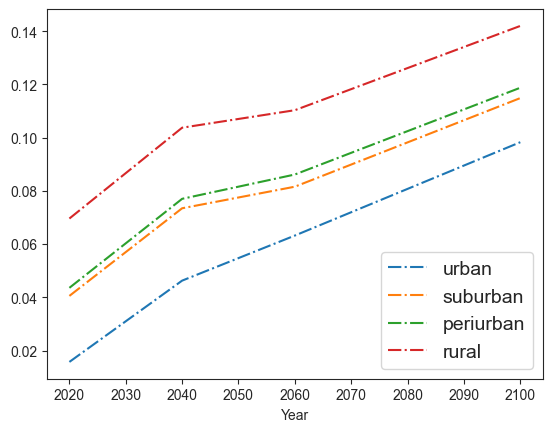

In [ ]:
df_decreasing  = roads_clean[roads_clean['future trend from SSP 2'] == 'decreasing']
x = [2020,2040,2060,2100] 
y1 = df_decreasing[df_decreasing['city type'] == 'urban'][['percent change from 2020-2040', 'percent change from 2040-2060', 'percent change from 2060-2080', 'percent change from 2080-2100']].mean(axis=0).values
y2 = df_decreasing[df_decreasing['city type'] == 'suburban'][['percent change from 2020-2040', 'percent change from 2040-2060', 'percent change from 2060-2080', 'percent change from 2080-2100']].mean(axis=0).values
y3 = df_decreasing[df_decreasing['city type'] == 'periurban'][['percent change from 2020-2040', 'percent change from 2040-2060', 'percent change from 2060-2080', 'percent change from 2080-2100']].mean(axis=0).values
y4 = df_decreasing[df_decreasing['city type'] == 'rural'][['percent change from 2020-2040', 'percent change from 2040-2060', 'percent change from 2060-2080', 'percent change from 2080-2100']].mean(axis=0).values
plt.plot(x, y1, '-.', label ='urban')
plt.plot(x, y2, '-.', label ='suburban')
plt.plot(x, y3, '-.', label ='periurban')
plt.plot(x, y4, '-.', label ='rural')
plt.xlabel("Year")
plt.legend()
# plt.title('multiple plots')
plt.show()

In [ ]:
# import plotly.express as px
# px_data = roads_clean
# fig = px.scatter(px_data, x=px_data.index, y='percent change from 2020-2040', color = 'future trend from SSP 2')
# # fig = px.scatter(px_data, x=px_data.index, y='percent change from 2060-2080', color = 'REGION')
# fig.show()

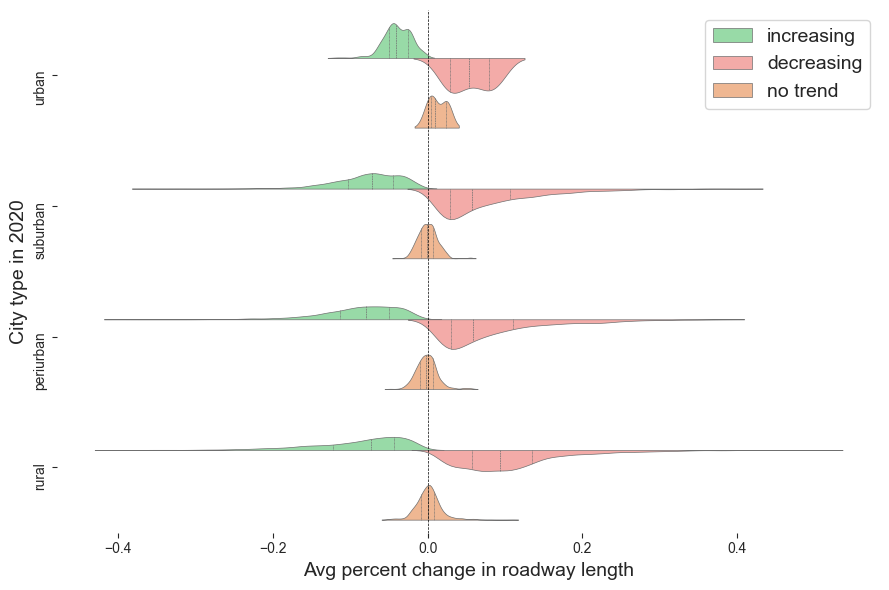

In [ ]:
roads_clean['avg_percent_change'] = roads_clean[['percent change from 2020-2040', 'percent change from 2040-2060', 
                                                 'percent change from 2060-2080', 'percent change from 2080-2100']].mean(axis=1)
fig, ax = plt.subplots(figsize=(9, 6))
sns.violinplot(ax=ax, data = roads_clean, y= 'city type', x= 'avg_percent_change', hue='future trend from SSP 2', split=True, inner="quart",
               order=['urban', 'suburban', 'periurban', 'rural'], palette = ['#8de5a1','#ff9f9b', '#ffb482'], linewidth=0.5)
ax.axvline(x = 0, linestyle = '--', linewidth = 0.5, color ='black') 
ax.set(frame_on=False)
# sns.set_style("whitegrid", {'axes.grid' : False})
plt.yticks(rotation=90, ha='right')
ax.legend(fontsize=14,)
ax.set_xlabel('Avg percent change in roadway length',fontsize=14)
ax.set_ylabel('City type in 2020',fontsize=14)
sns.set_style("ticks")
fig.tight_layout()
plt.savefig(r"D:\Work\Box Sync\Quantify Infrastructure\Figures\avg_percent_roadway_change.png", transparent=True)
# plt.legend(loc='lower right')
# plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

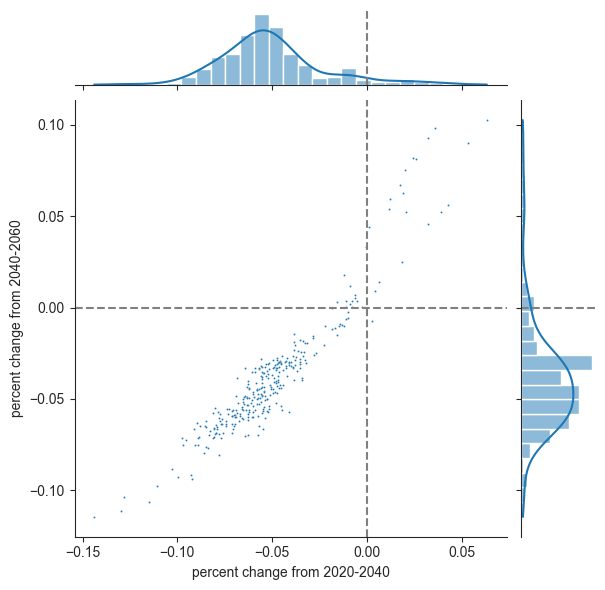

In [ ]:
g = sns.JointGrid(data=roads_clean[roads_clean['city type'] == 'urban'], x='percent change from 2020-2040', y = 'percent change from 2040-2060',)
g.plot_joint(sns.scatterplot, s=2, )
g.plot_marginals(sns.histplot, kde=True)
g.refline(x=0, y=0)

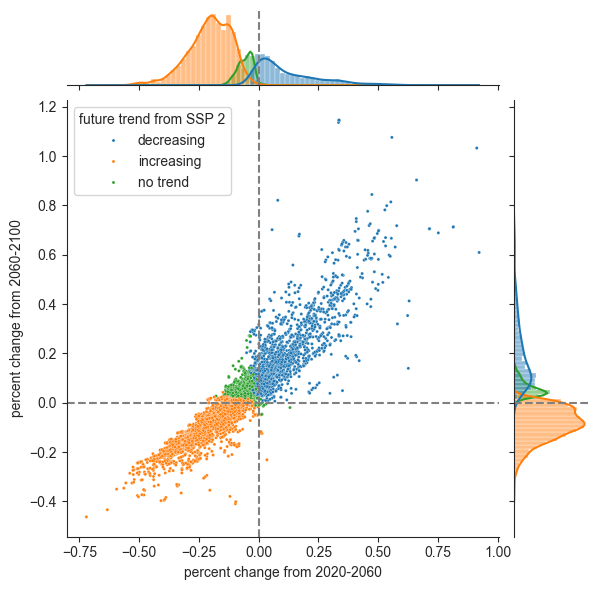

In [ ]:
plt.rc('legend',fontsize=10) 
g = sns.JointGrid(data=roads_df[roads_df['city type'] == 'suburban'], x='percent change from 2020-2060', y = 'percent change from 2060-2100',
                  marginal_ticks=False, hue="future trend from SSP 2")
g.plot_joint(sns.scatterplot, s=5, )
g.plot_marginals(sns.histplot, kde=True, linewidth =0.2)
g.refline(x=0, y=0)


In [ ]:
# print(sns.color_palette("pastel").as_hex())

In [ ]:
roads_df[roads_df['percent change from 2060-2100'] >= roads_df['percent change from 2020-2060']][['NAMELSAD', 'percent change from 2020-2060', 'percent change from 2060-2100',]].sort_values(by = 'percent change from 2060-2100')

,NAMELSAD,percent change from 2020-2060,percent change from 2060-2100
19428,Tioga city,-0.772481,-0.483198
19693,Trenton CDP,-0.769971,-0.482421
19427,Ray city,-0.765105,-0.480642
19681,Long Creek CDP,-0.757972,-0.478204
19351,Arnegard city,-0.798628,-0.474563
...,...,...,...
20635,Berlin CDP,0.110695,1.306195
20583,Killbuck village,0.111354,1.306962
20403,Nashville village,0.116203,1.309859
25806,Floydada city,0.588480,1.440580


In [ ]:
roads_df[roads_df['percent change from 2060-2100'] < roads_df['percent change from 2020-2060']][['NAMELSAD', 'percent change from 2020-2060', 'percent change from 2060-2100',]].sort_values(by = 'percent change from 2060-2100')

,NAMELSAD,percent change from 2020-2060,percent change from 2060-2100
24582,Cavour town,-0.416392,-0.484963
24930,Riverside Colony CDP,-0.415344,-0.483664
24817,Martin city,-0.254437,-0.468948
24840,Allen CDP,-0.253473,-0.465964
24819,Batesland town,-0.251445,-0.462850
...,...,...,...
17264,Watrous CDP,1.062500,1.000000
17088,Mora CDP,1.048689,1.022727
9292,Rolla city,1.219653,1.162500
9291,Elkhart city,1.234320,1.183463


#### Unused plots

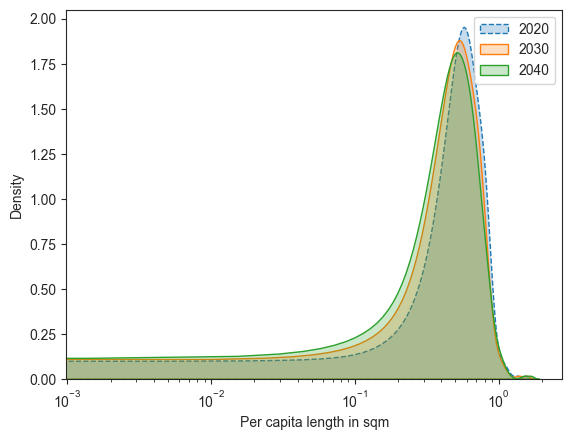

In [ ]:
df_plot_city = roads_clean[roads_clean['city type'] == 'urban']

fig, ax = plt.subplots()
sns.kdeplot(np.log10(df_plot_city['per_cap_mass_at_2020']), fill=True, ax=ax, linestyle="--") 
# sns.kdeplot(np.log10(df_plot_city['per_cap_mass_at_2030']), fill=True, ax=ax)
# sns.kdeplot(np.log10(df_plot_city['per_cap_mass_at_2040']), fill=True, ax=ax)
# sns.kdeplot(np.log10(df_plot_city['per_cap_mass_at_2050']), fill=True, ax=ax)
sns.kdeplot(np.log10(df_plot_city['per_cap_mass_at_2060']), fill=True, ax=ax)
# sns.kdeplot(np.log10(df_plot_city['per_cap_mass_at_2070']), fill=True, ax=ax)
# sns.kdeplot(np.log10(df_plot_city['per_cap_mass_at_2080']), fill=True, ax=ax)
# sns.kdeplot(np.log10(df_plot_city['per_cap_mass_at_2090']), fill=True, ax=ax)
sns.kdeplot(np.log10(df_plot_city['per_cap_mass_at_2100']), fill=True, ax=ax)
fig.canvas.draw()
locs, labels = plt.xticks()
plt.xscale('log')
plt.xlabel('Per capita length in sqm')
plt.legend(labels=['2020', '2030', '2040', '2050', '2060', '2070', '2080', '2090', '2100'])
# # Or for scientific notation:
# ax.set(xticklabels=["$10^" + i.get_text() + "$" for i in labels])
plt.show()

<Axes: xlabel='value', ylabel='Density'>

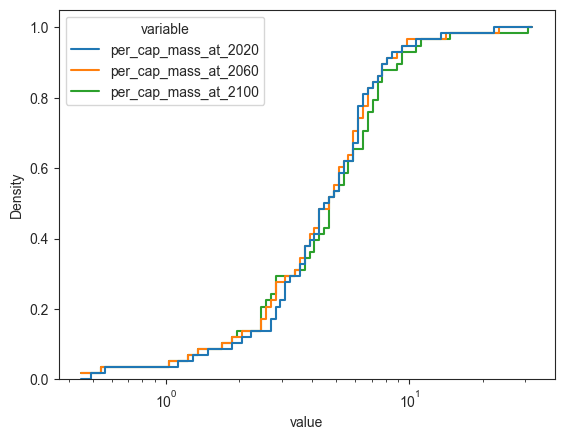

In [ ]:
# make dataframe
data = roads_clean[(roads_clean['city type'] == 'urban') & (roads_clean['label'].str.contains('depopulating'))]
df = data[['per_cap_mass_at_2020', 'per_cap_mass_at_2060', 'per_cap_mass_at_2100']]

# plot melted dataframe in a single command
sns.histplot(df.melt(), x='value', hue='variable', log_scale=True, bins=80, binwidth =0.02, shrink=.8, fill=False,
             cumulative=True, stat="density", common_norm=False,element="step",)